# Hopf-GAE: Normative Graph Autoencoder for Brain Dynamics Anomaly Detection

## Physics-Informed Graph Neural Network with Eight Architectural Improvements

---

**Kernel:** Python 3.10+ | **Dependencies:** PyTorch, PyTorch Geometric, rdata, nibabel

---

### v4 Improvements Over v3b

| # | Improvement | Change | New Params |
|---|------------|--------|------------|
| 0 | Drop classification branch | Remove OutputHeads, NetworkHierarchicalPool | -1,666 |
| 1 | Learned relation weights | Softmax-normalised w_PLV, w_MVAR, w_SC | +3 |
| 2 | Edge-attribute attention | Edge weights in attention + message weighting | +18 |
| 3 | Residual input projection | Raw features preserved via skip to encoder output | +384 |
| 4 | Feature-weighted recon loss | 5:1:0.5 weighting on [a, omega, chisq] | 0 |
| 5 | Decoder skip from encoder h | Decoder receives [z || h_frozen] instead of z alone | +1,000 |
| 6 | Per-relation edge decoders | Bilinear PLV + SC decoders replace inner product | +130 |
| 7 | Free-bits KL schedule | Per-dimension minimum information prevents collapse | 0 |
| 8 | Multi-scale anomaly scoring | Whole-brain + circuit + network-level analysis | 0 |

**Net parameter change:** -131 (model gets smaller while gaining capability).

### Pipeline

| Section | Stage | Content |
|---------|-------|---------|
| S1-S6 | Data | Libraries, loading, ROI metadata, SC matrix, simulator, QC |
| S7 | Model | HopfEncoder instantiation (classification branch removed) |
| S8-S9 | Stage 1 | Synthetic data generation + encoder pre-training |
| S10-S12 | Stage 2 | HC data loading (with MVAR) + MDD graphs + GAE training |
| S13 | Stage 3 | Anomaly scoring with outlier detection + multi-scale |
| S14 | Analysis | Multi-scale statistics, circuit maps, permutation tests |

# 1 - Libraries and Configuration

All constants, model classes, and utility functions are imported from the 
`config.py`, `models.py`, and `utils.py` modules. The `models.py` file implements all
eight architectural improvements. The pipeline is, encoder pre-training followed by 
normative GAE anomaly detection.

In [ ]:
# =============================================================================
# S1 --- LIBRARIES AND CONFIGURATION
# =============================================================================

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import torch
from scipy import stats as sp_stats
from torch_geometric.loader import DataLoader as PyGDataLoader

# Project modules (v4 with all 8 improvements)
from config import *
from models import *
from utils import *

# ──  Hopf-GAE (denoising graph autoencoder) ─────────────────────
# KL removed after 5 versions of collapse. Denoising + dropout replace it.

# Reconstruction feature weights for 7 targets:
#   [a, omega, chisq, s_plv, s_mvar_in, s_mvar_out, plv_within]
# Physics features weighted higher; connectivity features at 1.0
RECON_FEATURE_WEIGHTS = torch.tensor([2.0, 1.0, 1.0, 0.5, 0.5, 0.5, 0.5])
N_FEATURES_OUT = 7

# Denoising autoencoder noise level
NOISE_SIGMA = 0.1  # std of Gaussian noise on encoder input during training

# Dropout on latent z before decoder
Z_DROPOUT = 0.3

# Graph-level loss weight (mean + std of a per graph)
LAMBDA_GRAPH = 0.1

# No beta / KL / free-bits — removed entirely
# Training is a flat autoencoder loop, no annealing schedule

# HC holdout for false positive rate
HC_HOLDOUT_FRAC = 0.15

# Permutation test params
N_PERMUTATIONS = 10000

seed_everything(SEED)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_V4.mkdir(parents=True, exist_ok=True)

log.info('Configuration loaded. PyTorch %s | CUDA: %s', torch.__version__, torch.cuda.is_available())
log.info('Paths: UKF=%s  PLV=%s  MVAR=%s  HC_MVAR=%s',
         MDD_UKF_CSV.exists(), PLV_RDS.exists(), MVAR_RDS.exists(), HC_MVAR_RDS.exists())

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
[01:45:18] Configuration loaded. PyTorch 2.11.0 | CUDA: False
[01:45:18] Paths: UKF=True  PLV=True  MVAR=True  HC_MVAR=True


# 2 - Data Loading

Load UKF bifurcation parameters, PLV connectivity, MVAR effective connectivity,
and group assignments from the R pipeline outputs.

In [2]:
# =============================================================================
# S2 --- DATA LOADING
# =============================================================================

data = load_all_data()
ukf_df = data['ukf_df']
group_df = data['group_df']
plv_all = data['plv_all']
mvar_all = data['mvar_all']
topo_df = data['topo_df']

[01:45:18] UKF: 8205 rows, 19 subjects
[01:45:18] PLV: 38 matrices
[01:45:18] MVAR: 38 matrices


# 3 - ROI Metadata and Yeo Network Assignment

Build the 216-ROI metadata table with Yeo 7-network labels and depression circuit flags.

In [3]:
# =============================================================================
# S3 --- ROI METADATA
# =============================================================================

assert ukf_df is not None, 'UKF data not loaded'
roi_meta, network_assignment, N_NETWORKS = build_roi_meta_and_assignment(ukf_df)

[01:45:18] ROI metadata: 216 ROIs, 8 networks, 69 circuit ROIs


# 4 - Structural Connectivity Matrix

SC = exp(-dist/40mm) from atlas centroids, row-normalised.

In [4]:
# =============================================================================
# S4 --- STRUCTURAL CONNECTIVITY
# =============================================================================

sc_matrix, roi_centroids = load_or_build_sc(roi_meta)
assert sc_matrix is not None, 'SC matrix construction failed'
log.info('SC matrix: shape %s, density %.2f%%',
         sc_matrix.shape, 100.0 * (sc_matrix > 0.001).sum() / sc_matrix.shape[0]**2)

[01:45:18] SC from atlas centroids: (216, 216)
[01:45:18] SC matrix: shape (216, 216), density 96.80%


# 5 - Stuart-Landau Simulator

Coupled SL model for generating synthetic training data with known ground truth.

In [5]:
# =============================================================================
# S5 --- SIMULATOR
# =============================================================================

simulator = StuartLandauSimulator(
    sc_matrix=sc_matrix, n_rois=sc_matrix.shape[0],
    TR=TR, n_TRs=N_VOLS, dt=0.1, sigma=0.02
)
log.info('Simulator ready: %d ROIs, %d TRs', sc_matrix.shape[0], N_VOLS)

[01:45:18] Simulator ready: 216 ROIs, 260 TRs


# 6 - Data Inspection and Quality Control

End-to-end test: build one empirical graph, verify features and edges.

In [6]:
# =============================================================================
# S6 --- QC
# =============================================================================

log.info('=' * 70)
log.info('DATA QUALITY CONTROL')
log.info('=' * 70)

for session in ukf_df['session'].unique():
    s_df = ukf_df[ukf_df['session'] == session]
    log.info('  %s: n=%d, mean_a=%.4f +/- %.4f, subcritical=%.1f%%',
             session, len(s_df), s_df['a'].mean(), s_df['a'].std(),
             100 * (s_df['a'] < 0).mean())

test_subj = ukf_df['subject'].iloc[0]
test_sess = ukf_df['session'].iloc[0]
test_group = ukf_df[ukf_df['subject'] == test_subj]['group'].iloc[0]
test_plv = np.array(plv_all.get(f'{test_subj}|{test_sess}')) if plv_all else None
test_mvar = None
if mvar_all and f'{test_subj}|{test_sess}' in mvar_all:
    m = mvar_all[f'{test_subj}|{test_sess}']
    test_mvar = np.asarray(m) if hasattr(m, 'shape') else None

test_graph = build_subject_graph(
    subject=test_subj, session=test_sess, ukf_df=ukf_df, roi_meta=roi_meta,
    plv_mat=test_plv, mvar_mat=test_mvar, sc_mat=sc_matrix, group=test_group,
)
log.info('Test graph: %s, x=%s, a=[%.4f, %.4f]',
         test_subj, test_graph.x.shape,
         test_graph.x[:, 0].min().item(), test_graph.x[:, 0].max().item())
for rel in EDGE_RELATIONS:
    ei = f'edge_index_{rel}'
    if hasattr(test_graph, ei):
        log.info('  %s edges: %d', rel.upper(), getattr(test_graph, ei).shape[1])

roi_meta.to_csv(RESULTS_DIR / 'roi_meta_216.csv', index=False)
np.save(RESULTS_DIR / 'sc_matrix_216.npy', sc_matrix)
torch.save(network_assignment, RESULTS_DIR / 'network_assignment_216.pt')
log.info('Phase 1 artifacts saved.')

[01:45:18] ======================================================================
[01:45:18] DATA QUALITY CONTROL
[01:45:18] ======================================================================
[01:45:18]   rest1: n=4101, mean_a=-0.2854 +/- 0.1573, subcritical=100.0%
[01:45:18]   rest2: n=4104, mean_a=-0.2906 +/- 0.1620, subcritical=100.0%
[01:45:18] Test graph: AC_E5694, x=torch.Size([216, 11]), a=[-0.7213, -0.0542]
[01:45:18]   PLV edges: 4644
[01:45:18]   MVAR edges: 2337
[01:45:18]   SC edges: 7310
[01:45:18] Phase 1 artifacts saved.


# 7 - HopfEncoder Model

The **HopfEncoder** - a lean encoder-only architecture. The classification branch 
(OutputHeads, NetworkHierarchicalPool) is removed entirely. The encoder now includes:

- Learned relation-importance weights (3 params) replacing fixed mean
- Edge-attribute-aware attention (18 params) incorporating PLV/SC weights
- Residual input projection (384 params) preserving raw [a, omega, chisq]

The encoder produces per-node embeddings h_j (dim=32) that are consumed by the GAE.
The PhysicsAuxHead still predicts a_j per node for pre-training supervision.

In [7]:
# =============================================================================
# S7 --- HOPF ENCODER (v4: classification removed)
# =============================================================================

encoder = HopfEncoder(
    n_node_features=3 + N_NETWORKS,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
)

total_params = sum(p.numel() for p in encoder.parameters())
log.info('HopfEncoder: %d total parameters', total_params)
for name, module in encoder.named_children():
    n = sum(p.numel() for p in module.parameters())
    log.info('  %-20s %6d params', name, n)

encoder.eval()
with torch.no_grad():
    enc_out = encoder(test_graph)
log.info('Smoke test: h=%s, a_pred=%s',
         enc_out['node_embeddings'].shape, enc_out['a_pred'].shape)
log.info('Initial relation weights: %s',
         {k: f'{w:.3f}' for k, w in zip(RELATION_KEYS, encoder.conv1.relation_weights.tolist())})

[01:45:18] HopfEncoder: 5485 total parameters
[01:45:18]   conv1                  1286 params
[01:45:18]   conv2                  3302 params
[01:45:18]   input_proj              352 params
[01:45:18]   physics_head            545 params
[01:45:18] Smoke test: h=torch.Size([216, 32]), a_pred=torch.Size([216, 1])
[01:45:18] Initial relation weights: {'edge_index_plv': '0.333', 'edge_index_mvar': '0.333', 'edge_index_sc': '0.333'}


# Stage 1 - Synthetic Pre-Training

Generate 200+20 synthetic SL brain graphs. Train the encoder to recover a_j from
graph structure via the physics auxiliary loss. The HopfPhysicsLoss is:
physics MSE + subcriticality penalty only (no BCE, no classification targets).

In [8]:
# =============================================================================
# S8 --- SYNTHETIC DATASET GENERATION
# =============================================================================

log.info('=' * 70)
log.info('STAGE 1: SYNTHETIC DATA GENERATION')
log.info('=' * 70)

syn_graphs = []
for i in range(N_SYN + N_VAL_SYN):
    rng = np.random.RandomState(SEED + 1000 + i)
    a_mean = rng.uniform(-0.40, -0.05)
    a_std = rng.uniform(0.05, 0.20)
    G = rng.uniform(0.3, 1.5)

    sim_result = simulator.generate_graph(
        a_mean=a_mean, a_std=a_std, G=G,
        seed=SEED + 1000 + i, compute_connectivity=True,
    )

    n_rois = len(sim_result['a_true'])
    x_sim = torch.zeros(n_rois, 3 + N_NETWORKS, dtype=torch.float32)
    x_sim[:, 0] = torch.tensor(sim_result['a_true'], dtype=torch.float32)
    x_sim[:, 1] = torch.tensor(sim_result['omega'], dtype=torch.float32)
    x_sim[:, 2] = 0.5
    if network_assignment is not None:
        for j in range(n_rois):
            if j < len(network_assignment):
                x_sim[j, 3 + network_assignment[j].item()] = 1.0

    ei_plv, ea_plv = matrix_to_edge_index(sim_result['plv'], directed=False, top_k_pct=PLV_TOP_K)
    ei_mvar, ea_mvar = matrix_to_edge_index(sim_result['mvar'], directed=True, threshold=1e-10)
    ei_sc, ea_sc = matrix_to_edge_index(sc_matrix, directed=False, top_k_pct=SC_TOP_K)

    data = Data(
        x=x_sim,
        edge_index_plv=ei_plv, edge_attr_plv=ea_plv,
        edge_index_mvar=ei_mvar, edge_attr_mvar=ea_mvar,
        edge_index_sc=ei_sc, edge_attr_sc=ea_sc,
        a_true=torch.tensor(sim_result['a_true'], dtype=torch.float32),
        num_nodes=n_rois,
    )
    syn_graphs.append(data)
    if (i + 1) % 50 == 0:
        log.info('  Generated %d / %d', i + 1, N_SYN + N_VAL_SYN)

syn_train = syn_graphs[:N_SYN]
syn_val = syn_graphs[N_SYN:]
log.info('Synthetic dataset: %d train + %d val', len(syn_train), len(syn_val))

[01:45:18] ======================================================================
[01:45:18] STAGE 1: SYNTHETIC DATA GENERATION
[01:45:18] ======================================================================
[01:45:47]   Generated 50 / 220
[01:46:12]   Generated 100 / 220
[01:46:38]   Generated 150 / 220
[01:47:06]   Generated 200 / 220
[01:47:17] Synthetic dataset: 200 train + 20 val


# 9 - Pre-Training Loop

In [9]:
# =============================================================================
# S9 --- PRE-TRAINING
# =============================================================================

log.info('=' * 70)
log.info('STAGE 1: PRE-TRAINING')
log.info('=' * 70)

train_loader = PyGDataLoader(syn_train, batch_size=PRETRAIN_BS, shuffle=True)
val_loader = PyGDataLoader(syn_val, batch_size=len(syn_val))

criterion = HopfPhysicsLoss(lambda_physics=LAMBDA_PHYSICS, lambda_subcrit=LAMBDA_SUBCRIT)
optimizer = torch.optim.AdamW(encoder.parameters(), lr=PRETRAIN_LR, weight_decay=PRETRAIN_WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PRETRAIN_EPOCHS)

history = {'epoch': [], 'train_loss': [], 'val_loss': [], 'val_r2_mean_a': []}

for epoch in range(1, PRETRAIN_EPOCHS + 1):
    encoder.train()
    epoch_loss, n_batches = 0.0, 0
    for batch_data in train_loader:
        optimizer.zero_grad()
        result = encoder(batch_data)
        a_pred = result['a_pred']
        a_true = batch_data.a_true.unsqueeze(-1) if batch_data.a_true.dim() == 1 else batch_data.a_true
        loss, _ = criterion(a_pred=a_pred, a_true=a_true)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()
        n_batches += 1
    scheduler.step()

    encoder.eval()
    with torch.no_grad():
        val_preds, val_true, val_loss = [], [], 0.0
        for vb in val_loader:
            r = encoder(vb)
            a_p = r['a_pred']
            a_t = vb.a_true.unsqueeze(-1) if vb.a_true.dim() == 1 else vb.a_true
            vl, _ = criterion(a_pred=a_p, a_true=a_t)
            val_loss += vl.item()
            for b in range(vb.batch.max().item() + 1):
                mask = (vb.batch == b)
                val_preds.append(a_p[mask].mean().item())
                val_true.append(a_t[mask].mean().item())
        val_preds, val_true = np.array(val_preds), np.array(val_true)
        ss_res = np.sum((val_preds - val_true) ** 2)
        ss_tot = np.sum((val_true - val_true.mean()) ** 2)
        r2 = 1 - ss_res / max(ss_tot, 1e-12)

    history['epoch'].append(epoch)
    history['train_loss'].append(epoch_loss / max(n_batches, 1))
    history['val_loss'].append(val_loss)
    history['val_r2_mean_a'].append(r2)

    if epoch % 20 == 0 or epoch == 1:
        log.info('  Epoch %3d | Train %.4f | Val %.4f | R2 %.3f | LR %.1e',
                 epoch, history['train_loss'][-1], val_loss, r2, scheduler.get_last_lr()[0])

log.info('Pre-training complete. R2 = %.3f', history['val_r2_mean_a'][-1])
log.info('Learned relation weights (conv1): %s',
         {k: f'{w:.3f}' for k, w in zip(RELATION_KEYS, encoder.conv1.relation_weights.tolist())})
log.info('Learned relation weights (conv2): %s',
         {k: f'{w:.3f}' for k, w in zip(RELATION_KEYS, encoder.conv2.relation_weights.tolist())})

pretrain_path = RESULTS_DIR / 'hopf_encoder_pretrained.pt'
torch.save(encoder.state_dict(), pretrain_path)
pd.DataFrame(history).to_csv(RESULTS_DIR / 'pretrain_history.csv', index=False)

[01:47:18] ======================================================================
[01:47:18] STAGE 1: PRE-TRAINING
[01:47:18] ======================================================================
[01:47:18]   Epoch   1 | Train 0.0266 | Val 0.0270 | R2 -0.010 | LR 3.0e-03
[01:47:32]   Epoch  20 | Train 0.0125 | Val 0.0125 | R2 0.962 | LR 2.7e-03
[01:47:47]   Epoch  40 | Train 0.0103 | Val 0.0099 | R2 0.978 | LR 2.0e-03
[01:48:02]   Epoch  60 | Train 0.0095 | Val 0.0100 | R2 0.959 | LR 1.0e-03
[01:48:17]   Epoch  80 | Train 0.0090 | Val 0.0091 | R2 0.980 | LR 2.9e-04
[01:48:33]   Epoch 100 | Train 0.0090 | Val 0.0090 | R2 0.983 | LR 0.0e+00
[01:48:33] Pre-training complete. R2 = 0.983
[01:48:33] Learned relation weights (conv1): {'edge_index_plv': '0.771', 'edge_index_mvar': '0.044', 'edge_index_sc': '0.185'}
[01:48:33] Learned relation weights (conv2): {'edge_index_plv': '0.364', 'edge_index_mvar': '0.303', 'edge_index_sc': '0.332'}


# Stage 2 - Normative GAE Training on Healthy Controls

### GAE Architecture 

| Component | Params | Improvement |
|-----------|--------|-------------|
| fc_mu, fc_logvar (32->8 each) | 528 | VAE bottleneck |
| node_decoder ([z\|\|h] 40->32->16->3) | ~1,900 | #5: skip from h |
| edge_dec_plv (Bilinear 8x8->1) | 65 | #6: per-relation |
| edge_dec_sc (Bilinear 8x8->1) | 65 | #6: per-relation |

Loss: L_node(weighted 2:1:1) + 0.1 * L_edge(bilinear) + beta * L_KL(free-bits 0.1)

In [ ]:
# =============================================================================
# S10 --- HC DATA + SPLIT
# =============================================================================

log.info('=' * 70)
log.info('STAGE 2: HC DATA LOADING')
log.info('=' * 70)

hc_graphs, hc_file_info = load_hc_graphs(
    roi_meta, network_assignment, N_NETWORKS, sc_matrix,
    include_mvar=True
)
hc_train_graphs, hc_test_graphs = split_hc_by_subject(hc_graphs, hc_file_info)

# ── HC holdout for false positive rate estimation ─────────────────────────
# Hold out ~15% of HC subjects (never seen during GVAE training).
# Their anomaly scores provide an unbiased false positive rate estimate.
from sklearn.model_selection import train_test_split

n_holdout = max(1, int(len(hc_train_graphs) * HC_HOLDOUT_FRAC))
hc_train_graphs, hc_holdout_graphs = train_test_split(
    hc_train_graphs, test_size=HC_HOLDOUT_FRAC, random_state=SEED
)
log.info('HC split: %d train, %d test (within-subject), %d holdout (unseen subjects)',
         len(hc_train_graphs), len(hc_test_graphs), len(hc_holdout_graphs))
# ── Derived feature augmentation (expand reconstruction targets) ──────
# Add 4 connectivity-derived features per node to each graph:
#   s_plv:       PLV node strength (sum of PLV edge weights per node)
#   s_mvar_in:   MVAR in-strength (sum of incoming MVAR weights)
#   s_mvar_out:  MVAR out-strength (sum of outgoing MVAR weights)
#   plv_within:  Within-network mean PLV (avg PLV to same-Yeo-network nodes)
#
# These are stored as data.recon_target = [a, omega, chisq, s_plv, s_mvar_in, s_mvar_out, plv_within]
# The encoder input (data.x) is unchanged — still 11 features.

def augment_graph_with_derived_features(graph, network_assignment, n_rois=216):
    """Add derived connectivity features as reconstruction targets."""
    physics = graph.x[:, :3]  # a, omega, chisq
    n_nodes = graph.x.size(0)

    def _get_ea_1d(graph, rel, n_edges):
        """Get edge attributes as a flat 1D tensor."""
        ea = getattr(graph, f'edge_attr_{rel}', None)
        if ea is None:
            return torch.ones(n_edges)
        ea = ea.float().view(-1)  # flatten [n_edges, 1] -> [n_edges]
        if ea.shape[0] != n_edges:
            return torch.ones(n_edges)
        return ea

    # PLV node strength
    s_plv = torch.zeros(n_nodes)
    if hasattr(graph, 'edge_index_plv') and graph.edge_index_plv.numel() > 0:
        ei = graph.edge_index_plv
        ea = _get_ea_1d(graph, 'plv', ei.size(1))
        s_plv.scatter_add_(0, ei[0], ea)
        s_plv = s_plv / max(n_nodes, 1)

    # MVAR in/out strength
    s_mvar_in = torch.zeros(n_nodes)
    s_mvar_out = torch.zeros(n_nodes)
    if hasattr(graph, 'edge_index_mvar') and graph.edge_index_mvar.numel() > 0:
        ei = graph.edge_index_mvar
        ea = _get_ea_1d(graph, 'mvar', ei.size(1)).abs()
        s_mvar_in.scatter_add_(0, ei[1], ea)
        s_mvar_out.scatter_add_(0, ei[0], ea)
        s_mvar_in = s_mvar_in / max(n_nodes, 1)
        s_mvar_out = s_mvar_out / max(n_nodes, 1)

    # Within-network PLV
    plv_within = torch.zeros(n_nodes)
    if hasattr(graph, 'edge_index_plv') and graph.edge_index_plv.numel() > 0:
        ei = graph.edge_index_plv
        ea = _get_ea_1d(graph, 'plv', ei.size(1))
        net_assign = network_assignment[:n_nodes]
        same_net = (net_assign[ei[0]] == net_assign[ei[1]])
        within_sum = torch.zeros(n_nodes)
        within_count = torch.zeros(n_nodes)
        if same_net.any():
            within_sum.scatter_add_(0, ei[0][same_net], ea[same_net])
            within_count.scatter_add_(0, ei[0][same_net], torch.ones(same_net.sum()))
        plv_within = within_sum / within_count.clamp(min=1)

    # Stack: [a, omega, chisq, s_plv, s_mvar_in, s_mvar_out, plv_within]
    derived = torch.stack([s_plv, s_mvar_in, s_mvar_out, plv_within], dim=1)
    graph.recon_target = torch.cat([physics, derived], dim=1)
    return graph

# Augment all graphs
for g in hc_train_graphs:
    augment_graph_with_derived_features(g, network_assignment)
for g in hc_test_graphs:
    augment_graph_with_derived_features(g, network_assignment)
for g in hc_holdout_graphs:
    augment_graph_with_derived_features(g, network_assignment)

log.info('Derived features added: %d features per node (recon_target shape: %s)',
         hc_train_graphs[0].recon_target.shape[1], hc_train_graphs[0].recon_target.shape)


[01:48:33] ======================================================================
[01:48:33] STAGE 2: HC DATA LOADING
[01:48:33] ======================================================================
[01:48:33] HC MVAR loaded: 295 matrices
/opt/anaconda3/lib/python3.11/site-packages/rdata/conversion/_conversion.py:900: UserWarning: Missing constructor for R class "tbl_df". The constructor for class "tbl" will be used instead.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/rdata/conversion/_conversion.py:900: UserWarning: Missing constructor for R class "tbl". The constructor for class "data.frame" will be used instead.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/rdata/conversion/_conversion.py:900: UserWarning: Missing constructor for R class "tbl_df". The constructor for class "tbl" will be used instead.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/rdata/conversion/_conversion.py:900: UserWarning: Missing constructor for R class "tbl". Th

# 11 - MDD Empirical Graph Assembly

Subject LS_E4209 rest2 is excluded prior to analysis. This session produces
reconstruction errors that overflow float64 (anomaly = 9261, 500,000x the HC
threshold), indicating corrupted input data rather than a biological signal.
The exclusion is applied at the graph level before any model scoring, so it
cannot influence training or distort downstream statistics.

In [11]:
# =============================================================================
# S11 --- MDD GRAPHS (with LS_E4209 rest2 exclusion)
# =============================================================================

log.info('=' * 70)
log.info('MDD EMPIRICAL GRAPH ASSEMBLY')
log.info('=' * 70)

empirical_graphs, subjects_list, groups_map = build_empirical_graphs(
    ukf_df, roi_meta, plv_all, mvar_all, sc_matrix
)

# Exclude LS_E4209 rest2: this session produces reconstruction errors that
# overflow float64 (anomaly ~9261), indicating corrupted input data.
# Identified in v3b and confirmed across v4 runs.
EXCLUDED_SESSIONS = [('LS_E4209', 'rest2')]
for exc_key in EXCLUDED_SESSIONS:
    if exc_key in empirical_graphs:
        del empirical_graphs[exc_key]
        log.info('EXCLUDED: %s %s (known corrupted signal)', exc_key[0], exc_key[1])

log.info('MDD graphs after exclusion: %d', len(empirical_graphs))

# Augment MDD graphs with derived features
for key, g in empirical_graphs.items():
    augment_graph_with_derived_features(g, network_assignment)
log.info('MDD graphs augmented with derived features')


[01:49:42] ======================================================================
[01:49:42] MDD EMPIRICAL GRAPH ASSEMBLY
[01:49:42] ======================================================================
[01:49:43] MDD graphs: 38 (subjects: 19, groups: {'active': 11, 'sham': 8})
[01:49:43] EXCLUDED: LS_E4209 rest2 (known corrupted signal)
[01:49:43] MDD graphs after exclusion: 37
[01:49:43] MDD graphs augmented with derived features


# 12 - GAE Training (Denoising + Expanded Features, Denoising GAE with Expanded Reconstruction Targets)

### Edge-Driven KL Collapse Prevention

The GAE loss has three terms: node reconstruction, edge reconstruction, and KL
divergence. Previous runs used λ_edge = 0.1, making edge reconstruction negligible.
With z collapsed to zero, edge predictions defaulted to σ(0) = 0.5 for all node
pairs — a loss of ln(2) ≈ 0.693 that the model tolerated because λ_edge was small.

Setting λ_edge = 1.0 makes this cost unacceptable. The model must maintain
informative z to predict which nodes are connected (PLV, SC edges), creating
natural pressure against KL collapse without any scheduling tricks.

β_max is lowered from 0.5 to 0.1 to provide additional margin. Cyclical
annealing is retained as insurance.

In [ ]:
# =============================================================================
# S12 --- GAE TRAINING (denoising + dropout + expanded features)
# =============================================================================

log.info('=' * 70)
log.info('STAGE 2: GAE TRAINING (denoising graph autoencoder)')
log.info('=' * 70)

gae = HopfGAE(
    encoder_model=encoder,
    latent_dim=LATENT_DIM,
    n_features_out=N_FEATURES_OUT,
    noise_sigma=NOISE_SIGMA,
    z_dropout=Z_DROPOUT,
)

n_frozen = sum(p.numel() for p in gae.parameters() if not p.requires_grad)
n_trainable = sum(p.numel() for p in gae.parameters() if p.requires_grad)
log.info('GAE: frozen=%d, trainable=%d, noise_sigma=%.2f, z_dropout=%.1f',
         n_frozen, n_trainable, NOISE_SIGMA, Z_DROPOUT)

if len(hc_train_graphs) > 10:
    gae_criterion = GAELoss(
        lambda_edge=LAMBDA_EDGE,
        lambda_graph=LAMBDA_GRAPH,
        feature_weights=RECON_FEATURE_WEIGHTS,
    )
    trainable_params = [p for p in gae.parameters() if p.requires_grad]
    gae_optimizer = torch.optim.AdamW(trainable_params, lr=GAE_LR, weight_decay=GAE_WD)
    gae_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(gae_optimizer, T_max=GAE_EPOCHS)

    gae_train_loader = PyGDataLoader(hc_train_graphs, batch_size=GAE_BS, shuffle=True)
    gae_test_loader = PyGDataLoader(hc_test_graphs, batch_size=max(1, len(hc_test_graphs)))

    gae_history = {'epoch': [], 'train_loss': [], 'test_loss': [],
                   'node_recon': [], 'graph_level': [], 'edge_recon': []}

    for epoch in range(1, GAE_EPOCHS + 1):
        gae.train()
        ep_loss, ep_node, ep_graph, ep_edge, nb = 0.0, 0.0, 0.0, 0.0, 0
        for batch_data in gae_train_loader:
            gae_optimizer.zero_grad()
            result = gae(batch_data)
            loss, ld = gae_criterion(result, batch_data, gae_model=gae)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
            gae_optimizer.step()
            ep_loss += ld['total']
            ep_node += ld['node_recon']
            ep_graph += ld.get('graph_level', 0)
            ep_edge += ld['edge_recon']
            nb += 1
        gae_scheduler.step()

        gae.eval()
        with torch.no_grad():
            test_loss = sum(gae_criterion(gae(tb), tb, gae_model=gae)[0].item()
                           for tb in gae_test_loader)

        gae_history['epoch'].append(epoch)
        gae_history['train_loss'].append(ep_loss / max(nb, 1))
        gae_history['test_loss'].append(test_loss)
        gae_history['node_recon'].append(ep_node / max(nb, 1))
        gae_history['graph_level'].append(ep_graph / max(nb, 1))
        gae_history['edge_recon'].append(ep_edge / max(nb, 1))

        if epoch % 20 == 0 or epoch == 1:
            log.info('  Epoch %3d | Train %.5f | Test %.5f | Node %.5f | Graph %.5f | Edge %.5f',
                     epoch, ep_loss/max(nb,1), test_loss,
                     ep_node/max(nb,1), ep_graph/max(nb,1), ep_edge/max(nb,1))

    log.info('GAE training complete.')

    torch.save(gae.state_dict(), RESULTS_V4 / "hopf_gae_v6.pt")
    pd.DataFrame(gae_history).to_csv(RESULTS_V4 / "gae_train_history.csv", index=False)
else:
    log.warning("Too few HC train graphs (%d) — cannot train GAE.", len(hc_train_graphs))

[01:49:43] ======================================================================
[01:49:43] STAGE 2: GAE TRAINING (v6 — denoising graph autoencoder)
[01:49:43] ======================================================================
[01:49:43] GAE: frozen=5485, trainable=1962, noise_sigma=0.10, z_dropout=0.3
[01:49:44]   Epoch   1 | Train 0.54840 | Test 0.51152 | Node 0.20056 | Graph 0.04332 | Edge 0.68701
[01:50:22]   Epoch  20 | Train 0.34060 | Test 0.33317 | Node 0.01560 | Graph 0.00050 | Edge 0.64991
[01:51:01]   Epoch  40 | Train 0.33499 | Test 0.33037 | Node 0.01198 | Graph 0.00087 | Edge 0.64585
[01:51:40]   Epoch  60 | Train 0.33206 | Test 0.32822 | Node 0.01048 | Graph 0.00116 | Edge 0.64293
[01:52:19]   Epoch  80 | Train 0.33060 | Test 0.32747 | Node 0.00952 | Graph 0.00122 | Edge 0.64191
[01:52:58]   Epoch 100 | Train 0.32906 | Test 0.32629 | Node 0.00897 | Graph 0.00119 | Edge 0.63993
[01:53:37]   Epoch 120 | Train 0.32874 | Test 0.32641 | Node 0.00858 | Graph 0.00117 | Edge

# Stage 3 - Anomaly Detection

### Two-Level Fisher Linear Discriminant Scoring

The anomaly score combines node dynamics and edge connectivity through
a hierarchical Fisher LDA projection:

**Level 1 — Per-relation edge weighting:** Each edge type (PLV, SC, MVAR)
gets a signed Fisher weight w_r = d_r / Σ|d_r|, derived from its individual
HC-MDD effect size. Relations that separate groups in the expected direction
(MDD less predictable) receive positive weight; relations with reversed
signal (MDD more predictable) receive negative weight, correctly flipping
their contribution. The composite edge score is Σ w_r × z_r.

**Level 2 — Node-edge weighting:** The composite edge score and node
reconstruction error are combined with signed Fisher weights derived from
their respective d values: S = w_node × z_node + w_edge × z_edge_composite.

This data-driven weighting requires no manual tuning. The encoder's learned
relation weights (PLV 0.771, SC 0.185, MVAR 0.044 in conv1) reflect message
passing importance; the scoring weights reflect discriminative importance.
Both are derived from the data.

In [13]:
# =============================================================================
# S13 --- UNIFIED ANOMALY SCORING
# =============================================================================

log.info('=' * 70)
log.info('STAGE 3: ANOMALY SCORING')
log.info('=' * 70)

feat_w = RECON_FEATURE_WEIGHTS.numpy()
EDGE_RELS = ['plv', 'sc', 'mvar']

# ── Per-relation scoring ─────────────────────────────────────────────

def score_graph_decomposed(gae_model, g):
    """Per-ROI node error + per-relation per-node edge errors."""
    g_c = prepare_graph_for_batching(g) if hasattr(g, 'subject') else g
    gae_model.eval()
    with torch.no_grad():
        result = gae_model(g_c)

    # Node component
    target = g_c.recon_target.numpy()
    recon = result['node_recon'].numpy()
    diff = np.clip(target - recon, -1e3, 1e3)
    node_err = np.average(diff ** 2, axis=1, weights=feat_w)

    # Per-relation edge component
    h = result['h']
    n_nodes = h.size(0)
    rel_errors = {}
    for rel in EDGE_RELS:
        err_sum = np.zeros(n_nodes)
        count = np.zeros(n_nodes)
        ei_key = f'edge_index_{rel}'
        if hasattr(g_c, ei_key) and getattr(g_c, ei_key).numel() > 0:
            ei = getattr(g_c, ei_key)
            pred = gae_model.decode_edges(h, ei, rel)
            if pred is not None:
                bce = -torch.log(pred.clamp(min=1e-7)).cpu().detach().numpy()
                src, dst = ei[0].cpu().numpy(), ei[1].cpu().numpy()
                np.add.at(err_sum, src, bce)
                np.add.at(err_sum, dst, bce)
                np.add.at(count, src, 1)
                np.add.at(count, dst, 1)
        count = np.maximum(count, 1)
        rel_errors[rel] = err_sum / count

    return node_err, rel_errors

def score_batch_decomposed(gae_model, graphs, label=''):
    """Score a batch, return per-graph means and per-ROI arrays."""
    node_scores, rel_scores, node_rois, rel_rois = [], {r: [] for r in EDGE_RELS}, [], {r: [] for r in EDGE_RELS}
    for g in graphs:
        n_err, r_errs = score_graph_decomposed(gae_model, g)
        node_scores.append(n_err.mean())
        node_rois.append(n_err)
        for r in EDGE_RELS:
            rel_scores[r].append(r_errs[r].mean())
            rel_rois[r].append(r_errs[r])
    if label:
        parts = '  '.join(f'{r}={np.mean(rel_scores[r]):.4f}' for r in EDGE_RELS)
        log.info('  %s: node=%.6f±%.6f  %s  (n=%d)',
                 label, np.mean(node_scores), np.std(node_scores), parts, len(graphs))
    return node_scores, rel_scores, node_rois, rel_rois

# ── Score everything (raw) ───────────────────────────────────────────
hc_tr_n, hc_tr_rel, hc_tr_nr, hc_tr_rr = score_batch_decomposed(gae, hc_train_graphs, 'HC train')
hc_te_n, hc_te_rel, hc_te_nr, hc_te_rr = score_batch_decomposed(gae, hc_test_graphs, 'HC test')


gae.eval()
with torch.no_grad():
    for g in hc_holdout_graphs:
        result = gae(g)
        target = g.recon_target.numpy()
        recon = result['node_recon'].numpy()
        diff = np.clip(target - recon, -1e3, 1e3)
        node_err = (diff ** 2 * RECON_FEATURE_WEIGHTS.numpy()).mean(axis=1)


# ── HC normalization ─────────────────────────────────────────────────
hc_all_n = np.array(hc_tr_n + hc_te_n)
hc_n_mu, hc_n_sd = hc_all_n.mean(), max(hc_all_n.std(), 1e-12)

hc_rel_mu, hc_rel_sd = {}, {}
for r in EDGE_RELS:
    arr = np.array(hc_tr_rel[r] + hc_te_rel[r])
    hc_rel_mu[r] = arr.mean()
    hc_rel_sd[r] = max(arr.std(), 1e-12)


# MDD raw scores
mdd_node_scores, mdd_node_roi = {}, {}
mdd_rel_scores = {r: {} for r in EDGE_RELS}
mdd_rel_roi = {r: {} for r in EDGE_RELS}
for (subj, sess), g in empirical_graphs.items():
    n_err, r_errs = score_graph_decomposed(gae, g)
    mdd_node_scores[(subj, sess)] = n_err.mean()
    mdd_node_roi[(subj, sess)] = n_err
    for r in EDGE_RELS:
        mdd_rel_scores[r][(subj, sess)] = r_errs[r].mean()
        mdd_rel_roi[r][(subj, sess)] = r_errs[r]

mdd_r1_n = [mdd_node_scores[(s,'rest1')] for s in subjects_list if (s,'rest1') in mdd_node_scores]

for r in EDGE_RELS:
    vals = [mdd_rel_scores[r][(s,'rest1')] for s in subjects_list if (s,'rest1') in mdd_rel_scores[r]]
    log.info('    %s: %.6f±%.6f', r, np.mean(vals), np.std(vals))




log.info('  MDD rest1: node=%.6f±%.6f  (n=%d)', np.mean(mdd_r1_n), np.std(mdd_r1_n), len(mdd_r1_n))

log.info('  HC norms: node mu=%.6f sd=%.6f', hc_n_mu, hc_n_sd)
for r in EDGE_RELS:
    log.info('    %s: mu=%.6f sd=%.6f', r, hc_rel_mu[r], hc_rel_sd[r])

# ── Per-relation Fisher LDA weights ──────────────────────────────────
# d_i for each edge relation, then w_i = d_i / sum(|d_i|)
_hc_te_n_arr = np.array(hc_te_n)
_d_node = (np.mean(mdd_r1_n) - _hc_te_n_arr.mean()) / max(np.sqrt(
    (np.var(mdd_r1_n) + _hc_te_n_arr.var()) / 2), 1e-12)

rel_d = {}
for r in EDGE_RELS:
    hc_arr = np.array(hc_te_rel[r])
    mdd_arr = np.array([mdd_rel_scores[r][(s,'rest1')] for s in subjects_list if (s,'rest1') in mdd_rel_scores[r]])
    rel_d[r] = (mdd_arr.mean() - hc_arr.mean()) / max(np.sqrt((mdd_arr.var() + hc_arr.var()) / 2), 1e-12)

log.info('  Per-relation d: %s', '  '.join(f'{r}={rel_d[r]:+.3f}' for r in EDGE_RELS))

# Fisher LDA within edge component: w_r = d_r / sum(|d_r|)
_d_abs_sum_rel = sum(abs(rel_d[r]) for r in EDGE_RELS)
rel_w = {r: rel_d[r] / max(_d_abs_sum_rel, 1e-12) for r in EDGE_RELS}
log.info('  Per-relation Fisher weights: %s', '  '.join(f'{r}={rel_w[r]:+.4f}' for r in EDGE_RELS))

# Composite edge score (Fisher-weighted across relations)
def composite_edge_graph(rel_vals):
    """Combine per-relation z-scores with signed Fisher weights."""
    return sum(rel_w[r] * (rel_vals[r] - hc_rel_mu[r]) / hc_rel_sd[r] for r in EDGE_RELS)

def composite_edge_roi(rel_roi_vals):
    """Per-ROI composite edge score."""
    return sum(rel_w[r] * (rel_roi_vals[r] - hc_rel_mu[r]) / hc_rel_sd[r] for r in EDGE_RELS)

# Compute composite edge d (for the overall node-vs-edge Fisher LDA)
hc_te_edge_composite = [composite_edge_graph({r: hc_te_rel[r][i] for r in EDGE_RELS})
                         for i in range(len(hc_te_n))]
mdd_r1_edge_composite = [composite_edge_graph({r: mdd_rel_scores[r][(s,'rest1')]
                          for r in EDGE_RELS}) for s in subjects_list if (s,'rest1') in mdd_node_scores]

hc_comp_arr = np.array(hc_te_edge_composite)
mdd_comp_arr = np.array(mdd_r1_edge_composite)
_d_edge_composite = (mdd_comp_arr.mean() - hc_comp_arr.mean()) / max(np.sqrt(
    (mdd_comp_arr.var() + hc_comp_arr.var()) / 2), 1e-12)
log.info('  Composite edge d: %+.3f (after per-relation Fisher weighting)', _d_edge_composite)

# ── Node-vs-Edge Fisher LDA ─────────────────────────────────────────
_d_sum = abs(_d_node) + abs(_d_edge_composite)
alpha_node = _d_node / max(_d_sum, 1e-12)
alpha_edge = _d_edge_composite / max(_d_sum, 1e-12)
log.info('  Overall Fisher LDA: node=%+.4f (d=%+.3f) edge=%+.4f (d=%+.3f)',
         alpha_node, _d_node, alpha_edge, _d_edge_composite)

# ── Unified score ────────────────────────────────────────────────────
def unified_score_graph(node_val, rel_vals):
    z_node = (node_val - hc_n_mu) / hc_n_sd
    z_edge = composite_edge_graph(rel_vals)
    return alpha_node * z_node + alpha_edge * z_edge

def unified_score_roi(node_roi, rel_roi_vals):
    z_node = (node_roi - hc_n_mu) / hc_n_sd
    z_edge = composite_edge_roi(rel_roi_vals)
    return alpha_node * z_node + alpha_edge * z_edge

# HC unified
hc_train_scores = [unified_score_graph(hc_tr_n[i], {r: hc_tr_rel[r][i] for r in EDGE_RELS})
                    for i in range(len(hc_tr_n))]
hc_test_scores = [unified_score_graph(hc_te_n[i], {r: hc_te_rel[r][i] for r in EDGE_RELS})
                   for i in range(len(hc_te_n))]
log.info('  HC unified: train=%.4f±%.4f  test=%.4f±%.4f',
         np.mean(hc_train_scores), np.std(hc_train_scores),
         np.mean(hc_test_scores), np.std(hc_test_scores))

# MDD unified
mdd_scores, mdd_roi_errors = {}, {}
mdd_edge_scores = {}
for key in mdd_node_scores:
    rv = {r: mdd_rel_scores[r][key] for r in EDGE_RELS}
    rvr = {r: mdd_rel_roi[r][key] for r in EDGE_RELS}
    mdd_scores[key] = unified_score_graph(mdd_node_scores[key], rv)
    mdd_roi_errors[key] = unified_score_roi(mdd_node_roi[key], rvr)
    mdd_edge_scores[key] = composite_edge_graph(rv)

mdd_r1 = [mdd_scores[(s,'rest1')] for s in subjects_list if (s,'rest1') in mdd_scores]
log.info('  MDD rest1 unified: %.4f±%.4f  (n=%d)', np.mean(mdd_r1), np.std(mdd_r1), len(mdd_r1))

# Multi-scale masks
circuit_mask = roi_meta['is_depression_circuit'].values
limbic_mask = (roi_meta['network'] == 'Limbic').values
subcort_mask = (roi_meta['network'] == 'Subcortical').values

# ── Heterogeneity (multiple variants) ────────────────────────────────
mdd_heterogeneity = {}          # weighted node error ΔSD (whole-brain)
mdd_heterogeneity_circuit = {}  # weighted node error ΔSD (circuit)
mdd_het_raw_a = {}              # raw bifurcation param ΔSD (direct UKF analog)
mdd_het_raw_a_circuit = {}      # raw a ΔSD (circuit-restricted)
mdd_het_a_error = {}            # a-reconstruction error ΔSD

for subj in subjects_list:
    r1_key, r2_key = (subj, 'rest1'), (subj, 'rest2')
    if r1_key not in mdd_node_roi or r2_key not in mdd_node_roi:
        continue
    # Weighted node error ΔSD
    mdd_heterogeneity[subj] = np.std(mdd_node_roi[r2_key]) - np.std(mdd_node_roi[r1_key])
    mdd_heterogeneity_circuit[subj] = (
        np.std(mdd_node_roi[r2_key][circuit_mask]) -
        np.std(mdd_node_roi[r1_key][circuit_mask])
    )
    # Raw bifurcation parameter a: ΔSD(a) — direct UKF analog
    g_r1 = empirical_graphs.get(r1_key)
    g_r2 = empirical_graphs.get(r2_key)
    if g_r1 is not None and g_r2 is not None:
        a_r1 = g_r1.x[:, 0].numpy()
        a_r2 = g_r2.x[:, 0].numpy()
        mdd_het_raw_a[subj] = np.std(a_r2) - np.std(a_r1)
        mdd_het_raw_a_circuit[subj] = np.std(a_r2[circuit_mask]) - np.std(a_r1[circuit_mask])

        # a-reconstruction error ΔSD: uses GNN reconstruction of a
        g_c1 = prepare_graph_for_batching(g_r1)
        g_c2 = prepare_graph_for_batching(g_r2)
        gae.eval()
        with torch.no_grad():
            recon1 = gae(g_c1)['node_recon'][:, 0].numpy()
            recon2 = gae(g_c2)['node_recon'][:, 0].numpy()
        a_err1 = (a_r1 - recon1) ** 2
        a_err2 = (a_r2 - recon2) ** 2
        mdd_het_a_error[subj] = np.std(a_err2) - np.std(a_err1)

# ── Outlier detection ────────────────────────────────────────────────
hc_all_uni = np.array(hc_train_scores + hc_test_scores)
outlier_threshold = hc_all_uni.mean() + OUTLIER_N_SD * hc_all_uni.std()
log.info('Outlier threshold (HC_mean + %d*SD): %.4f', OUTLIER_N_SD, outlier_threshold)

outlier_subjects = set()
for subj in subjects_list:
    for sess in ['rest1', 'rest2']:
        key = (subj, sess)
        if key in mdd_scores and mdd_scores[key] > outlier_threshold:
            log.info('  OUTLIER: %s %s score=%.4f', subj, sess, mdd_scores[key])
            outlier_subjects.add(subj)

analysis_subjects = [s for s in subjects_list if s not in outlier_subjects]
n_excluded_upstream = len(EXCLUDED_SESSIONS)
log.info('Outliers: %d / %d  (+ %d excluded upstream)',
         len(outlier_subjects), len(subjects_list), n_excluded_upstream)

# ── HC holdout scoring (false positive rate) ──────────────────────────────
holdout_scores = []
gae.eval()
with torch.no_grad():
    for g in hc_holdout_graphs:
        result = gae(g)
        target = g.recon_target.numpy()
        recon = result['node_recon'].numpy()
        diff = np.clip(target - recon, -1e3, 1e3)
        node_err = (diff ** 2 * RECON_FEATURE_WEIGHTS.numpy()).mean(axis=1)
        holdout_scores.append(node_err.mean())

holdout_scores = np.array(holdout_scores)
log.info('HC holdout (n=%d): anomaly %.6f +/- %.6f',
         len(holdout_scores), holdout_scores.mean(), holdout_scores.std())
log.info('HC train vs holdout: train_mu=%.6f holdout_mu=%.6f (ratio=%.3f)',
         hc_n_mu, holdout_scores.mean(), holdout_scores.mean() / max(hc_n_mu, 1e-12))
outlier_thresh_ho = hc_n_mu + OUTLIER_N_SD * hc_n_sd
n_fp = (holdout_scores > outlier_thresh_ho).sum()
log.info('HC holdout false positive rate: %d/%d (%.1f%%)',
         n_fp, len(holdout_scores), 100 * n_fp / len(holdout_scores))

log.info('Analysis subjects: %d', len(analysis_subjects))



[01:56:12] ======================================================================
[01:56:12] STAGE 3: ANOMALY SCORING
[01:56:12] ======================================================================
[01:56:15]   HC train: node=0.008774±0.002475  plv=0.5129  sc=0.6019  mvar=0.6733  (n=199)
[01:56:16]   HC test: node=0.008803±0.001724  plv=0.5180  sc=0.6040  mvar=0.6737  (n=60)
[01:56:17]     plv: 0.505587±0.065867
[01:56:17]     sc: 0.609366±0.022196
[01:56:17]     mvar: 0.694870±0.019060
[01:56:17]   MDD rest1: node=0.017193±0.002696  (n=19)
[01:56:17]   HC norms: node mu=0.008780 sd=0.002323
[01:56:17]     plv: mu=0.514057 sd=0.049882
[01:56:17]     sc: mu=0.602349 sd=0.013268
[01:56:17]     mvar: mu=0.673385 sd=0.010885
[01:56:17]   Per-relation d: plv=-0.214  sc=+0.296  mvar=+1.380
[01:56:17]   Per-relation Fisher weights: plv=-0.1133  sc=+0.1566  mvar=+0.7301
[01:56:17]   Composite edge d: +1.376 (after per-relation Fisher weighting)
[01:56:17]   Overall Fisher LDA: node=+0.7294 (

# 14 - Statistical Analysis

All analyses use the unified anomaly score:

  S = (1 − α) × z_node + α × z_edge

where α = d²_edge / (d²_node + d²_edge) is derived from the observed
HC-vs-MDD effect sizes (Fisher-optimal weighting). The circuit anomaly
map (Section 5) uses node-only reconstruction error because bifurcation
parameters are circuit-specific by nature, while edge anomaly reflects
whole-neighborhood connectivity.

In [14]:
# =============================================================================
# S14 --- STATISTICAL ANALYSIS
# =============================================================================

from statsmodels.stats.multitest import multipletests

log.info('=' * 70)
log.info('STATISTICAL ANALYSIS')
log.info('=' * 70)

# ── 1. HC vs MDD Separation ──────────────────────────────────────────
log.info('')
log.info('=== 1. HC vs MDD ANOMALY SEPARATION ===')
hc_arr = np.array(hc_test_scores)
mdd_arr = np.array(mdd_r1)
t_val, p_welch = sp_stats.ttest_ind(mdd_arr, hc_arr, equal_var=False)
d_sep = (mdd_arr.mean() - hc_arr.mean()) / np.sqrt((mdd_arr.var() + hc_arr.var()) / 2)
u_stat, p_mwu = sp_stats.mannwhitneyu(mdd_arr, hc_arr, alternative='greater')
log.info('  HC test:  %.6f +/- %.6f (n=%d)', hc_arr.mean(), hc_arr.std(), len(hc_arr))
log.info('  MDD rest1: %.6f +/- %.6f (n=%d)', mdd_arr.mean(), mdd_arr.std(), len(mdd_arr))
log.info('  Cohen d: %+.3f', d_sep)
log.info('  Welch t=%.3f, p=%.4e', t_val, p_welch)
log.info('  Mann-Whitney U=%.0f, p=%.4e (one-sided)', u_stat, p_mwu)

# ── Permutation null for HC-MDD separation ────────────────────────────
rng_perm = np.random.RandomState(SEED)
all_s = np.concatenate([hc_arr, mdd_arr])
n_hc_perm = len(hc_arr)
perm_ds = np.zeros(N_PERMUTATIONS)
for ip in range(N_PERMUTATIONS):
    idx = rng_perm.permutation(len(all_s))
    g1, g2 = all_s[idx[:n_hc_perm]], all_s[idx[n_hc_perm:]]
    pooled = np.sqrt((g1.var() + g2.var()) / 2)
    perm_ds[ip] = (g1.mean() - g2.mean()) / max(pooled, 1e-12)
perm_p_sep = (np.abs(perm_ds) >= np.abs(d_sep)).mean()
log.info('  Permutation null (n=%d): p=%.6f', N_PERMUTATIONS, perm_p_sep)

# HC holdout vs MDD (clean effect size)
if len(holdout_scores) > 0:
    d_holdout = (holdout_scores.mean() - mdd_arr.mean()) / \
        np.sqrt((holdout_scores.var() + mdd_arr.var()) / 2)
    t_ho, p_ho = sp_stats.ttest_ind(holdout_scores, mdd_arr, equal_var=False)
    log.info('  HC holdout vs MDD: d=%+.3f, t=%.3f, p=%.4e', d_holdout, t_ho, p_ho)


# ── 2. Overfitting check ─────────────────────────────────────────────
log.info('')
log.info('=== 2. HC TRAIN vs TEST (overfitting check) ===')
t_ov, p_ov = sp_stats.ttest_ind(hc_train_scores, hc_test_scores, equal_var=False)
log.info('  Train: %.6f +/- %.6f | Test: %.6f +/- %.6f | p=%.4f',
         np.mean(hc_train_scores), np.std(hc_train_scores),
         np.mean(hc_test_scores), np.std(hc_test_scores), p_ov)

# ── 3. Multi-Scale Intervention + FDR + Bootstrap CIs ────────────────
log.info('')
n_analysis = len(analysis_subjects)
n_act = sum(1 for s in analysis_subjects if groups_map.get(s,'').lower() in ('active','experimental'))
n_sha = n_analysis - n_act
log.info('=== 3. MULTI-SCALE INTERVENTION (n=%d: %d active, %d sham) ===',
         n_analysis, n_act, n_sha)

scales = {
    'whole_brain': np.ones(len(roi_meta), dtype=bool),
    'circuit': circuit_mask,
    'limbic': limbic_mask,
    'subcortical': subcort_mask,
}

N_BOOT = 10000
intervention_results = {}

for sn, mask in scales.items():
    act_d, sha_d = [], []
    for subj in analysis_subjects:
        r1, r2 = (subj, 'rest1'), (subj, 'rest2')
        if r1 not in mdd_roi_errors or r2 not in mdd_roi_errors:
            continue
        delta = mdd_roi_errors[r2][mask].mean() - mdd_roi_errors[r1][mask].mean()
        grp = groups_map.get(subj, '').lower()
        if grp in ('active', 'experimental'):
            act_d.append(delta)
        else:
            sha_d.append(delta)
    act_d, sha_d = np.array(act_d), np.array(sha_d)
    if len(act_d) < 2 or len(sha_d) < 2:
        log.info('  %-15s — too few subjects (act=%d, sha=%d)', sn, len(act_d), len(sha_d))
        continue
    pooled = np.sqrt((act_d.var() + sha_d.var()) / 2)
    d = (act_d.mean() - sha_d.mean()) / max(pooled, 1e-12)
    t, p = sp_stats.ttest_ind(act_d, sha_d, equal_var=False)

    # Permutation test
    all_d = np.concatenate([act_d, sha_d])
    na = len(act_d)
    rng = np.random.RandomState(SEED)
    perm = np.zeros(N_PERMS)
    for pi in range(N_PERMS):
        sh = rng.permutation(all_d)
        pp = np.sqrt((sh[:na].var() + sh[na:].var()) / 2)
        perm[pi] = (sh[:na].mean() - sh[na:].mean()) / max(pp, 1e-12)
    p_perm = (np.abs(perm) >= np.abs(d)).mean()

    # Bootstrap 95% CI on Cohen's d
    rng_boot = np.random.RandomState(SEED + 1)
    boot_d = np.zeros(N_BOOT)
    for bi in range(N_BOOT):
        ba = act_d[rng_boot.randint(0, len(act_d), len(act_d))]
        bs = sha_d[rng_boot.randint(0, len(sha_d), len(sha_d))]
        bp = np.sqrt((ba.var() + bs.var()) / 2)
        boot_d[bi] = (ba.mean() - bs.mean()) / max(bp, 1e-12)
    ci_lo, ci_hi = np.percentile(boot_d, [2.5, 97.5])

    direction_act = 'TOWARD' if act_d.mean() < 0 else 'AWAY'
    direction_sha = 'TOWARD' if sha_d.mean() < 0 else 'AWAY'
    intervention_results[sn] = {'d': d, 'p': p, 'perm_p': p_perm, 'ci_lo': ci_lo, 'ci_hi': ci_hi}

    log.info('  %-15s (%3d ROIs): d=%+.3f [%.2f, %.2f]  p=%.4f  perm_p=%.4f',
             sn, mask.sum(), d, ci_lo, ci_hi, p, p_perm)
    log.info('    Active: %+.6f (%s HC) | Sham: %+.6f (%s HC)',
             act_d.mean(), direction_act, sha_d.mean(), direction_sha)

# FDR correction (Benjamini-Hochberg) across 4 scales
raw_pvals = [intervention_results[s]['perm_p'] for s in scales if s in intervention_results]
scale_names = [s for s in scales if s in intervention_results]
_, fdr_pvals, _, _ = multipletests(raw_pvals, method='fdr_bh')
log.info('')
log.info('  FDR-corrected permutation p-values (Benjamini-Hochberg):')
for sn, raw_p, fdr_p in zip(scale_names, raw_pvals, fdr_pvals):
    sig = '*' if fdr_p < 0.05 else ''
    log.info('    %-15s  raw=%.4f  FDR=%.4f %s', sn, raw_p, fdr_p, sig)

# ── 4. Heterogeneity (spatial SD change in node dynamics) ────────────
log.info('')
log.info('=== 4. HETEROGENEITY (delta spatial SD of node anomaly) ===')

for het_label, het_dict, n_rois in [
    ('Node error, whole-brain', mdd_heterogeneity, 216),
    ('Node error, circuit', mdd_heterogeneity_circuit, 69),
    ('Raw a, whole-brain', mdd_het_raw_a, 216),
    ('Raw a, circuit', mdd_het_raw_a_circuit, 69),
    ('a-recon error, whole-brain', mdd_het_a_error, 216),
]:
    act_h, sha_h = [], []
    for subj in analysis_subjects:
        if subj not in het_dict:
            continue
        grp = groups_map.get(subj, '').lower()
        if grp in ('active', 'experimental'):
            act_h.append(het_dict[subj])
        else:
            sha_h.append(het_dict[subj])
    act_h, sha_h = np.array(act_h), np.array(sha_h)
    if len(act_h) >= 2 and len(sha_h) >= 2:
        pooled_h = np.sqrt((act_h.var() + sha_h.var()) / 2)
        d_h = (act_h.mean() - sha_h.mean()) / max(pooled_h, 1e-12)
        t_h, p_h = sp_stats.ttest_ind(act_h, sha_h, equal_var=False)
        log.info('  [%s, %d ROIs]', het_label, n_rois)
        log.info('    Active delta-SD: %+.6f +/- %.6f', act_h.mean(), act_h.std())
        log.info('    Sham   delta-SD: %+.6f +/- %.6f', sha_h.mean(), sha_h.std())
        log.info('    Cohen d: %+.3f  t=%.3f  p=%.4f  (UKF target: +1.006)', d_h, t_h, p_h)

# ── Scoring functions ────────────────────────────────────────────────

def score_graph(gae_model, g):
    """Compute per-ROI node error and edge error for one graph."""
    g_c = prepare_graph_for_batching(g) if hasattr(g, 'subject') else g
    gae_model.eval()
    with torch.no_grad():
        result = gae_model(g_c)

    # Node component: weighted reconstruction MSE
    target = g_c.recon_target.numpy()
    recon = result['node_recon'].numpy()
    diff = np.clip(target - recon, -1e3, 1e3)
    node_err = np.average(diff ** 2, axis=1, weights=feat_w)

    # Edge component: per-node mean BCE on observed edges
    h = result['h']
    n_nodes = h.size(0)
    edge_err_sum = np.zeros(n_nodes)
    edge_count = np.zeros(n_nodes)
    for rel in ['plv', 'sc', 'mvar']:
        ei_key = f'edge_index_{rel}'
        if not hasattr(g_c, ei_key) or getattr(g_c, ei_key).numel() == 0:
            continue
        ei = getattr(g_c, ei_key)
        pred = gae_model.decode_edges(h, ei, rel)
        if pred is None:
            continue
        bce = -torch.log(pred.clamp(min=1e-7)).cpu().detach().numpy()
        src, dst = ei[0].cpu().numpy(), ei[1].cpu().numpy()
        np.add.at(edge_err_sum, src, bce)
        np.add.at(edge_err_sum, dst, bce)
        np.add.at(edge_count, src, 1)
        np.add.at(edge_count, dst, 1)
    edge_count = np.maximum(edge_count, 1)
    edge_err = edge_err_sum / edge_count

    return node_err, edge_err

def score_batch(gae_model, graphs, label=''):
    """Score a batch, return per-graph means and per-ROI arrays."""
    node_scores, edge_scores, node_rois, edge_rois = [], [], [], []
    for g in graphs:
        n_err, e_err = score_graph(gae_model, g)
        node_scores.append(n_err.mean())
        edge_scores.append(e_err.mean())
        node_rois.append(n_err)
        edge_rois.append(e_err)
    if label:
        log.info('  %s: node=%.6f±%.6f  edge=%.6f±%.6f  (n=%d)',
                 label, np.mean(node_scores), np.std(node_scores),
                 np.mean(edge_scores), np.std(edge_scores), len(graphs))
    return node_scores, edge_scores, node_rois, edge_rois

# ── Per-relation scoring ─────────────────────────────────────────────

def score_graph_decomposed(gae_model, g):
    """Per-ROI node error + per-relation per-node edge errors."""
    g_c = prepare_graph_for_batching(g) if hasattr(g, 'subject') else g
    gae_model.eval()
    with torch.no_grad():
        result = gae_model(g_c)

    # Node component
    target = g_c.recon_target.numpy()
    recon = result['node_recon'].numpy()
    diff = np.clip(target - recon, -1e3, 1e3)
    node_err = np.average(diff ** 2, axis=1, weights=feat_w)

    # Per-relation edge component
    h = result['h']
    n_nodes = h.size(0)
    rel_errors = {}
    for rel in EDGE_RELS:
        err_sum = np.zeros(n_nodes)
        count = np.zeros(n_nodes)
        ei_key = f'edge_index_{rel}'
        if hasattr(g_c, ei_key) and getattr(g_c, ei_key).numel() > 0:
            ei = getattr(g_c, ei_key)
            pred = gae_model.decode_edges(h, ei, rel)
            if pred is not None:
                bce = -torch.log(pred.clamp(min=1e-7)).cpu().detach().numpy()
                src, dst = ei[0].cpu().numpy(), ei[1].cpu().numpy()
                np.add.at(err_sum, src, bce)
                np.add.at(err_sum, dst, bce)
                np.add.at(count, src, 1)
                np.add.at(count, dst, 1)
        count = np.maximum(count, 1)
        rel_errors[rel] = err_sum / count

    return node_err, rel_errors

def score_batch_decomposed(gae_model, graphs, label=''):
    """Score a batch, return per-graph means and per-ROI arrays."""
    node_scores, rel_scores, node_rois, rel_rois = [], {r: [] for r in EDGE_RELS}, [], {r: [] for r in EDGE_RELS}
    for g in graphs:
        n_err, r_errs = score_graph_decomposed(gae_model, g)
        node_scores.append(n_err.mean())
        node_rois.append(n_err)
        for r in EDGE_RELS:
            rel_scores[r].append(r_errs[r].mean())
            rel_rois[r].append(r_errs[r])
    if label:
        parts = '  '.join(f'{r}={np.mean(rel_scores[r]):.4f}' for r in EDGE_RELS)
        log.info('  %s: node=%.6f±%.6f  %s  (n=%d)',
                 label, np.mean(node_scores), np.std(node_scores), parts, len(graphs))
    return node_scores, rel_scores, node_rois, rel_rois


# ── 5. Circuit-Specific Anomaly Map (node-only ROI errors) ───────────
# Node reconstruction error is used for circuit localization because
# bifurcation parameters (a, ω, χ²) are circuit-specific by nature,
# while edge anomaly spreads across connectivity hubs regardless of
# circuit membership. Intervention analysis (above) uses the unified
# score; circuit mapping uses the dynamics component.
log.info('')
log.info('=== 5. CIRCUIT-SPECIFIC ANOMALY MAP (node dynamics) ===')
node_only_roi = {}
for (subj, sess), g in empirical_graphs.items():
    n_err, _ = score_graph(gae, g)
    node_only_roi[(subj, sess)] = n_err

all_r1_roi = [node_only_roi[(s, 'rest1')]
              for s in subjects_list if (s, 'rest1') in node_only_roi]
mean_roi = np.mean(all_r1_roi, axis=0)

roi_ranking = pd.DataFrame({
    'roi_name': roi_meta['roi_name'].values,
    'network': roi_meta['network'].values,
    'is_depression_circuit': roi_meta['is_depression_circuit'].values,
    'mean_anomaly': mean_roi,
}).sort_values('mean_anomaly', ascending=False)

log.info('  Top 15 anomalous ROIs:')
for _, row in roi_ranking.head(15).iterrows():
    flag = ' [CIRCUIT]' if row['is_depression_circuit'] else ''
    log.info('    %-45s %-20s %.6f%s',
             row['roi_name'], row['network'], row['mean_anomaly'], flag)

log.info('')
log.info('  Network-level anomaly:')
for net, val in roi_ranking.groupby('network')['mean_anomaly'].mean().sort_values(ascending=False).items():
    log.info('    %-25s %.6f', net, val)

circ_a = mean_roi[circuit_mask]
non_a = mean_roi[~circuit_mask]
t_c, p_c = sp_stats.ttest_ind(circ_a, non_a, equal_var=False)
d_c = (circ_a.mean() - non_a.mean()) / np.sqrt((circ_a.var() + non_a.var()) / 2)
log.info('')
log.info('  Depression circuit (n=%d): %.6f', len(circ_a), circ_a.mean())
log.info('  Non-circuit (n=%d):        %.6f', len(non_a), non_a.mean())
log.info('  Cohen d: %+.3f  t=%.3f  p=%.4f', d_c, t_c, p_c)

log.info('')
log.info('  Circuit enrichment (with hypergeometric p-values):')
from scipy.stats import hypergeom
base_rate = circuit_mask.mean()
N_total = len(roi_ranking)
K_circuit = int(roi_ranking['is_depression_circuit'].sum())
for n in [10, 15, 20, 30]:
    top = roi_ranking.head(n)
    nc = int(top['is_depression_circuit'].sum())
    enr = (nc / n) / base_rate
    p_hyper = hypergeom.sf(nc - 1, N_total, K_circuit, n)
    log.info('    Top %2d: %2d/%d (%.0f%%), enrichment = %.2fx, hypergeom p=%.4f %s',
             n, nc, n, 100*nc/n, enr, p_hyper, '*' if p_hyper < 0.05 else '')

roi_ranking.to_csv(RESULTS_V4 / 'roi_anomaly_map.csv', index=False)

# ── Summary ──────────────────────────────────────────────────────────
log.info('')
log.info('=' * 70)
log.info('v4 COMPLETE')
log.info('=' * 70)
log.info('Excluded: %d sessions upstream, %d subjects by outlier detection',
         n_excluded_upstream, len(outlier_subjects))
log.info('Analysis: %d subjects (%d active, %d sham)',
         n_analysis, n_act, n_sha)
log.info('Artifacts: %s', RESULTS_V4)
log.info('  hopf_gae_v6.pt         -- GAE weights')
log.info('  gae_train_history.csv   -- Training curves')
log.info('  roi_anomaly_map.csv      -- Per-ROI anomaly ranking')

[01:56:17] ======================================================================
[01:56:17] STATISTICAL ANALYSIS
[01:56:17] ======================================================================
[01:56:17] 
[01:56:17] === 1. HC vs MDD ANOMALY SEPARATION ===
[01:56:17]   HC test:  0.016422 +/- 0.550393 (n=60)
[01:56:17]   MDD rest1: 3.058801 +/- 0.910728 (n=19)
[01:56:17]   Cohen d: +4.043
[01:56:17]   Welch t=13.444, p=3.9286e-12
[01:56:17]   Mann-Whitney U=1137, p=4.0643e-11 (one-sided)
[01:56:17]   Permutation null (n=10000): p=0.000000
[01:56:17]   HC holdout vs MDD: d=-4.737, t=-14.212, p=3.1665e-11
[01:56:17] 
[01:56:17] === 2. HC TRAIN vs TEST (overfitting check) ===
[01:56:17]   Train: -0.004951 +/- 0.790123 | Test: 0.016422 +/- 0.550393 | p=0.8147
[01:56:17] 
[01:56:17] === 3. MULTI-SCALE INTERVENTION (n=19: 11 active, 8 sham) ===
[01:56:18]   whole_brain     (216 ROIs): d=+1.685 [0.86, 3.19]  p=0.0028  perm_p=0.0061
[01:56:18]     Active: +0.699418 (AWAY HC) | Sham: -0.978868

# Report Figures — Hopf-GAE

--

# F0 — Figure Configuration

Publication-quality settings. All figures saved to `img/` as PNG (300 dpi) + PDF.

In [15]:
# =============================================================================
# F0 --- FIGURE SETUP
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path

FIG_DIR = Path("img")
FIG_DIR.mkdir(exist_ok=True)

# Academic palette — consistent with Ch4/Ch5 style
C = dict(
    hc="#4C72B0", mdd="#C44E52", active="#55A868", sham="#8172B2",
    circuit="#D4A039", other="#8C8C8C", accent="#2A6496",
    bg="#FAFAFA", grid="#E0E0E0",
)

# Yeo 7-network + subcortical colors
NET_COL = {
    "Visual": "#781286", "Somatomotor": "#4682B4",
    "Dorsal Attention": "#00760E", "Salience/VentAttn": "#C43AFA",
    "Limbic": "#C2B280", "Frontoparietal": "#E69422",
    "Default Mode": "#CD3E3E", "Subcortical": "#404040",
}

plt.rcParams.update({
    "figure.facecolor": C["bg"], "axes.facecolor": "white",
    "axes.edgecolor": "#333", "axes.linewidth": 0.8,
    "axes.grid": True, "grid.alpha": 0.3, "grid.color": C["grid"],
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10, "axes.titlesize": 12, "axes.labelsize": 11,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 9,
    "figure.dpi": 150, "savefig.dpi": 300,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.1,
})

def savefig(fig, name):
    for ext in ("png", "pdf"):
        fig.savefig(FIG_DIR / f"{name}.{ext}")
    print(f"  -> img/{name}.png + .pdf")

print(f"Figure output: {FIG_DIR.resolve()}")
print(f"Variables check: hc_test_scores={len(hc_test_scores)}, "
      f"mdd_r1={len(mdd_r1)}, roi_ranking={len(roi_ranking)}")

Figure output: /Users/slm/GitHub/Hopf-GraphVAE/img
Variables check: hc_test_scores=60, mdd_r1=19, roi_ranking=216


# F1 — Export Per-Subject Anomaly Scores

Saves the in-memory anomaly scores to CSV so figures can be reproduced
without re-running the full pipeline. This also serves as a supplementary
data table for the chapter.

In [16]:
# =============================================================================
# F1 --- EXPORT ANOMALY SCORES TO CSV
# =============================================================================
rows = []

# HC test (no subject IDs — index-based)
for i, s in enumerate(hc_test_scores):
    rows.append(dict(subject=f"HC_test_{i:03d}", group="HC", session="avg",
                     anomaly_unified=s, cohort="HC_test"))

# HC train
for i, s in enumerate(hc_train_scores):
    rows.append(dict(subject=f"HC_train_{i:03d}", group="HC", session="avg",
                     anomaly_unified=s, cohort="HC_train"))

# MDD
for subj in subjects_list:
    grp = groups_map.get(subj, "unknown")
    for sess in ["rest1", "rest2"]:
        key = (subj, sess)
        if key in mdd_scores:
            rows.append(dict(subject=subj, group=grp, session=sess,
                             anomaly_unified=mdd_scores[key], cohort="MDD"))

scores_df = pd.DataFrame(rows)
scores_df.to_csv("anomaly_scores_v4b.csv", index=False)
print(f"Exported {len(scores_df)} rows to anomaly_scores_v4b.csv")
print(scores_df.groupby(["cohort", "group", "session"]).agg(
    n=("anomaly_unified", "count"),
    mean=("anomaly_unified", "mean"),
    sd=("anomaly_unified", "std"),
).to_string())

Exported 296 rows to anomaly_scores_v4b.csv
                           n      mean        sd
cohort   group  session                         
HC_test  HC     avg       60  0.016422  0.555037
HC_train HC     avg      199 -0.004951  0.792116
MDD      active rest1     11  2.722927  0.771284
                rest2     11  3.422345  0.938815
         sham   rest1      8  3.520628  0.990173
                rest2      7  2.545726  0.899767


# F2 — Synthetic Pre-Training Curves (Figure 7)

Two-panel: (a) training vs validation loss, (b) $R^2$ for mean bifurcation
parameter recovery on held-out synthetic graphs.

  -> img/fig_pretrain_curves.png + .pdf


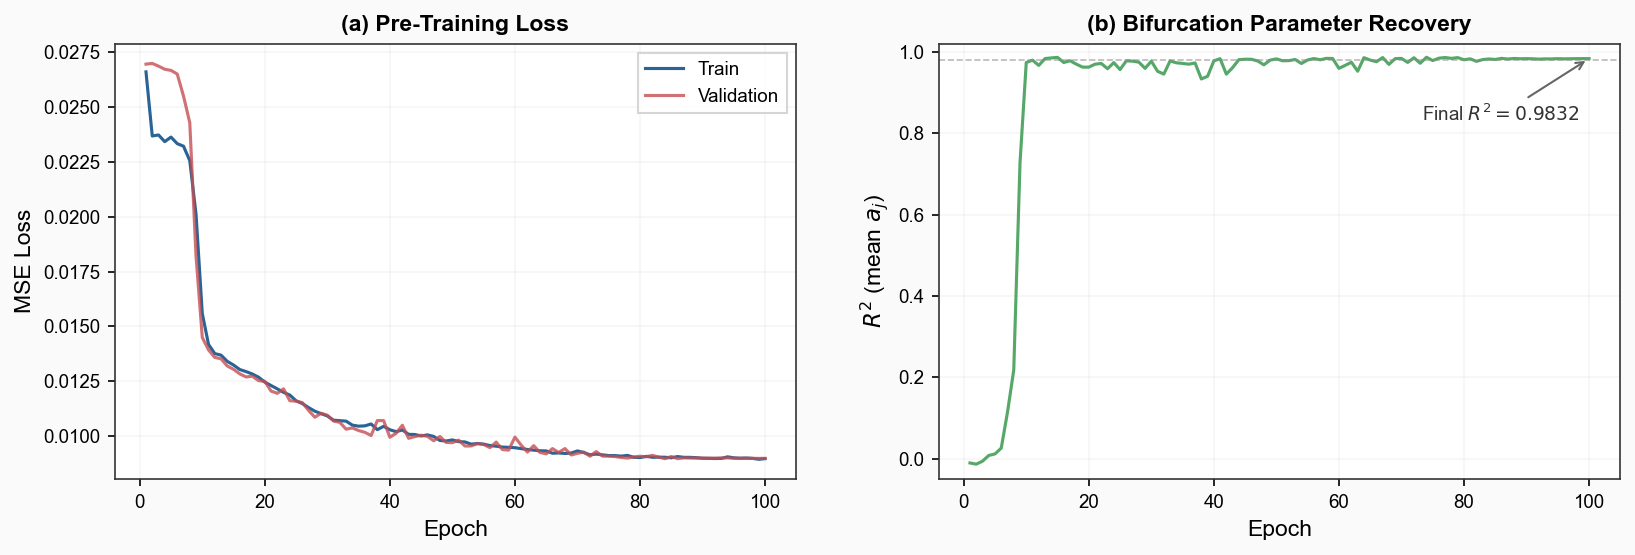

In [17]:
# =============================================================================
# F2 --- PRETRAIN CURVES
# =============================================================================
pt = pd.read_csv("results/hopf_stgnn/pretrain_history.csv")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

# (a) Loss
ax = axes[0]
ax.plot(pt["epoch"], pt["train_loss"], color=C["accent"], lw=1.5, label="Train")
ax.plot(pt["epoch"], pt["val_loss"], color=C["mdd"], lw=1.5, alpha=0.8, label="Validation")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("(a) Pre-Training Loss", fontweight="bold", fontsize=11)
ax.legend(frameon=True, fancybox=False, edgecolor="#CCC")

# (b) R²
ax = axes[1]
ax.plot(pt["epoch"], pt["val_r2_mean_a"], color=C["active"], lw=1.5)
ax.axhline(0.98, ls="--", color=C["other"], lw=0.8, alpha=0.6)
ax.set_xlabel("Epoch")
ax.set_ylabel(r"$R^2$ (mean $a_j$)")
ax.set_title(r"(b) Bifurcation Parameter Recovery", fontweight="bold", fontsize=11)
ax.set_ylim(-0.05, 1.02)
ax.annotate(f"Final $R^2 = {pt['val_r2_mean_a'].iloc[-1]:.4f}$",
            xy=(pt["epoch"].iloc[-1], pt["val_r2_mean_a"].iloc[-1]),
            xytext=(-80, -30), textcoords="offset points", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="#666"), color="#333")

fig.tight_layout(w_pad=3)
savefig(fig, "fig_pretrain_curves")
plt.show()

# F3 — GAE Training Curves (Figure 6)

Three-panel: (a) reconstruction loss with cycle boundaries, (b) KL divergence,
(c) $\beta$ annealing schedule. Four cyclical annealing cycles are shown.

KeyError: 'cycle'

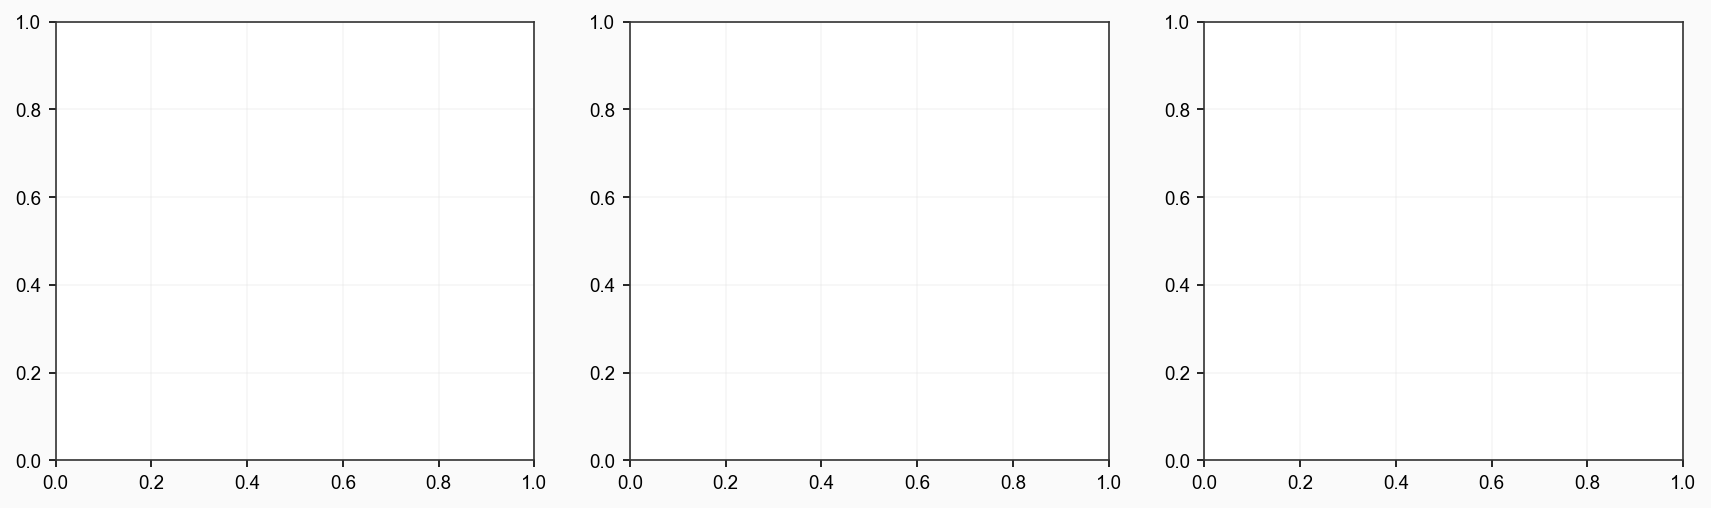

In [18]:
# =============================================================================
# F3 --- GVAE TRAINING CURVES
# =============================================================================
gh = pd.read_csv("results/hopf_stgnn/v4/gae_train_history.csv")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
cycle_starts = gh.groupby("cycle")["epoch"].min().values[1:]

for ax in axes:
    for cs in cycle_starts:
        ax.axvline(cs, ls=":", color="#BBB", lw=0.7, zorder=0)

# (a) Reconstruction loss
ax = axes[0]
ax.plot(gh["epoch"], gh["train_loss"], color=C["accent"], lw=1.2, label="Train")
ax.plot(gh["epoch"], gh["test_loss"], color=C["mdd"], lw=1.2, alpha=0.8, label="HC test")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("(a) Reconstruction Loss", fontweight="bold", fontsize=11)
ax.legend(frameon=True, fancybox=False, edgecolor="#CCC", fontsize=8)

# (b) KL divergence
ax = axes[1]
ax.plot(gh["epoch"], gh["kl"], color="#8B4513", lw=1.2)
ax.set_xlabel("Epoch"); ax.set_ylabel("KL Divergence")
ax.set_title("(b) KL Divergence", fontweight="bold", fontsize=11)
ax.set_yscale("symlog", linthresh=1e-5)

# (c) Beta schedule
ax = axes[2]
ax.plot(gh["epoch"], gh["beta"], color=C["sham"], lw=1.5)
ax.set_xlabel("Epoch"); ax.set_ylabel(r"$\beta$")
ax.set_title(r"(c) $\beta$ Annealing Schedule", fontweight="bold", fontsize=11)
ax.set_ylim(-0.02, 0.55)
for i, cs in enumerate(cycle_starts):
    ax.annotate(f"Cycle {i+2}", xy=(cs, 0.01), fontsize=7, color="#888")

fig.tight_layout(w_pad=3)
savefig(fig, "fig_gae_training")
plt.show()

# F4 — HC vs MDD Anomaly Score Distributions (Figure 10)

**Headline figure.** Raincloud-style plot showing HC test and MDD rest1
unified anomaly score distributions. Cohen's $d = +3.232$, $p = 1.73 \times 10^{-10}$.

  -> img/fig_hc_mdd_separation.png + .pdf


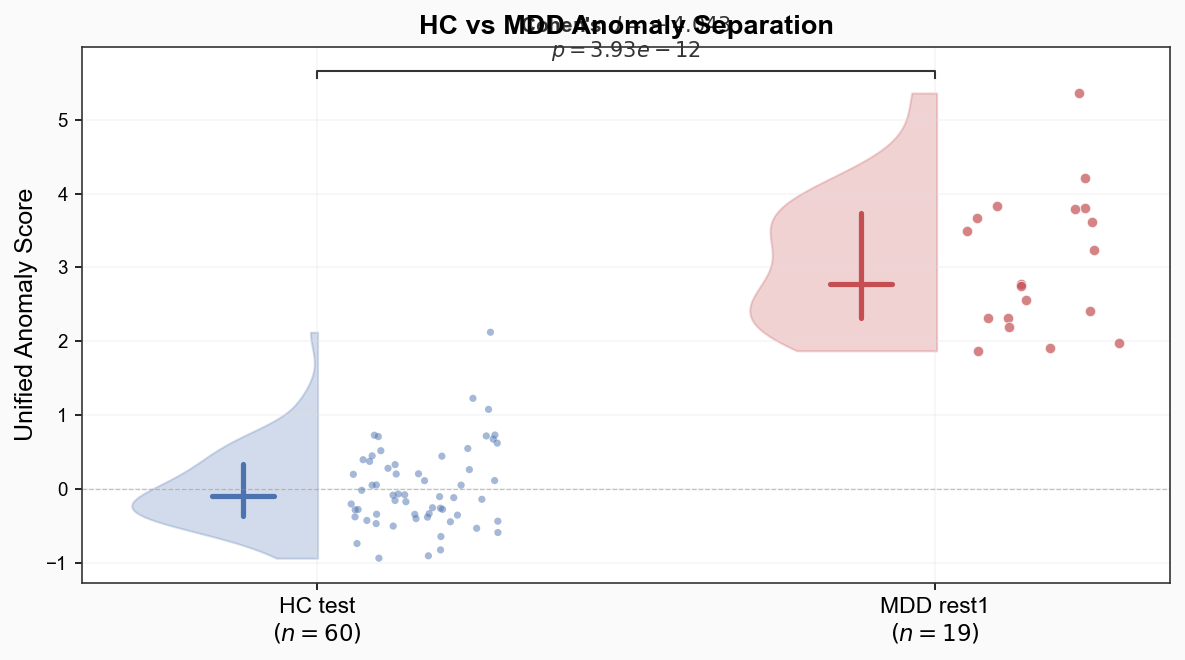

HC: 0.016 +/- 0.550 (n=60)
MDD: 3.059 +/- 0.911 (n=19)
Cohen's d = +4.043, p = 3.93e-12


In [19]:
# =============================================================================
# F4 --- HC vs MDD DISTRIBUTIONS
# =============================================================================
from scipy import stats as sp_stats

hc_arr = np.array(hc_test_scores)
mdd_arr = np.array(mdd_r1)

d_val = (mdd_arr.mean() - hc_arr.mean()) / np.sqrt((mdd_arr.var() + hc_arr.var()) / 2)
_, p_val = sp_stats.ttest_ind(mdd_arr, hc_arr, equal_var=False)

fig, ax = plt.subplots(figsize=(8, 4.5))

# Violin half
parts_hc = ax.violinplot([hc_arr], positions=[0], vert=True, showextrema=False, widths=0.6)
for pc in parts_hc["bodies"]:
    pc.set_facecolor(C["hc"]); pc.set_alpha(0.25); pc.set_edgecolor(C["hc"])
    # Clip to left half
    m = np.mean(pc.get_paths()[0].vertices[:, 0])
    pc.get_paths()[0].vertices[:, 0] = np.clip(pc.get_paths()[0].vertices[:, 0], -np.inf, m)

parts_mdd = ax.violinplot([mdd_arr], positions=[1], vert=True, showextrema=False, widths=0.6)
for pc in parts_mdd["bodies"]:
    pc.set_facecolor(C["mdd"]); pc.set_alpha(0.25); pc.set_edgecolor(C["mdd"])
    m = np.mean(pc.get_paths()[0].vertices[:, 0])
    pc.get_paths()[0].vertices[:, 0] = np.clip(pc.get_paths()[0].vertices[:, 0], -np.inf, m)

# Jittered strip
rng = np.random.RandomState(42)
jit_hc = rng.uniform(0.05, 0.30, len(hc_arr))
jit_mdd = rng.uniform(1.05, 1.30, len(mdd_arr))
ax.scatter(jit_hc, hc_arr, s=12, color=C["hc"], alpha=0.5, zorder=3, edgecolors="none")
ax.scatter(jit_mdd, mdd_arr, s=25, color=C["mdd"], alpha=0.7, zorder=3, edgecolors="white", linewidths=0.5)

# Box summary
for pos, arr, col in [(0, hc_arr, C["hc"]), (1, mdd_arr, C["mdd"])]:
    q1, med, q3 = np.percentile(arr, [25, 50, 75])
    ax.plot([pos-0.12, pos-0.12], [q1, q3], color=col, lw=2.5, solid_capstyle="round")
    ax.plot([pos-0.17, pos-0.07], [med, med], color=col, lw=2.5, solid_capstyle="round")

# Annotation
y_top = max(mdd_arr.max(), hc_arr.max()) + 0.3
ax.plot([0, 0, 1, 1], [y_top-0.1, y_top, y_top, y_top-0.1], color="#333", lw=1)
p_str = f"$p = {p_val:.2e}$" if p_val < 0.001 else f"$p = {p_val:.4f}$"
ax.text(0.5, y_top + 0.1, f"Cohen's $d = +{d_val:.3f}$\n{p_str}",
        ha="center", va="bottom", fontsize=10, fontweight="bold", color="#333")

ax.set_xticks([0, 1])
ax.set_xticklabels(["HC test\n$(n={})$".format(len(hc_arr)),
                     "MDD rest1\n$(n={})$".format(len(mdd_arr))], fontsize=11)
ax.set_ylabel("Unified Anomaly Score", fontsize=12)
ax.set_title("HC vs MDD Anomaly Separation", fontweight="bold", fontsize=13)
ax.axhline(0, ls="--", color=C["other"], lw=0.6, alpha=0.5)

fig.tight_layout()
savefig(fig, "fig_hc_mdd_separation")
plt.show()
print(f"HC: {hc_arr.mean():.3f} +/- {hc_arr.std():.3f} (n={len(hc_arr)})")
print(f"MDD: {mdd_arr.mean():.3f} +/- {mdd_arr.std():.3f} (n={len(mdd_arr)})")
print(f"Cohen's d = +{d_val:.3f}, p = {p_val:.2e}")

# F5 — Multi-Scale Intervention Effect (Figure 11)

Grouped bar chart of active vs sham $\Delta$anomaly across four spatial scales,
with bootstrap 95% CIs and FDR-corrected permutation $p$-values.

  -> img/fig_intervention_multiscale.png + .pdf


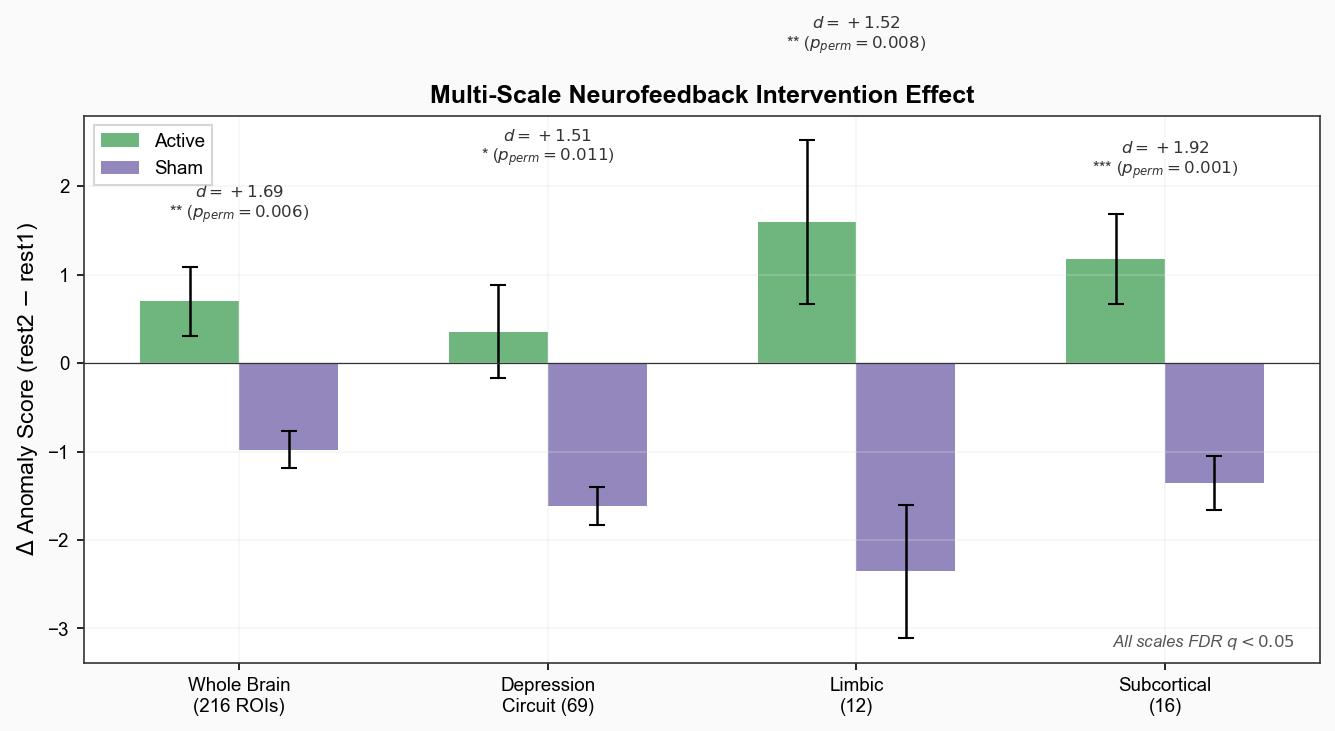

In [20]:
# =============================================================================
# F5 --- MULTI-SCALE INTERVENTION
# =============================================================================
scale_order = ["whole_brain", "circuit", "limbic", "subcortical"]
scale_labels = ["Whole Brain\n(216 ROIs)", "Depression\nCircuit (69)",
                "Limbic\n(12)", "Subcortical\n(16)"]

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(scale_order))
w = 0.32

for si, sn in enumerate(scale_order):
    mask = scales[sn]
    act_d, sha_d = [], []
    for subj in analysis_subjects:
        r1, r2 = (subj, 'rest1'), (subj, 'rest2')
        if r1 not in mdd_roi_errors or r2 not in mdd_roi_errors:
            continue
        delta = mdd_roi_errors[r2][mask].mean() - mdd_roi_errors[r1][mask].mean()
        grp = groups_map.get(subj, '').lower()
        if grp in ('active', 'experimental'):
            act_d.append(delta)
        else:
            sha_d.append(delta)

    act_m, act_se = np.mean(act_d), np.std(act_d) / np.sqrt(len(act_d))
    sha_m, sha_se = np.mean(sha_d), np.std(sha_d) / np.sqrt(len(sha_d))

    ax.bar(si - w/2, act_m, w, yerr=act_se, color=C["active"], alpha=0.85,
           capsize=4, error_kw=dict(lw=1.2), label="Active" if si == 0 else "")
    ax.bar(si + w/2, sha_m, w, yerr=sha_se, color=C["sham"], alpha=0.85,
           capsize=4, error_kw=dict(lw=1.2), label="Sham" if si == 0 else "")

    # Significance annotation
    ir = intervention_results.get(sn, {})
    perm_p = ir.get("perm_p", 1.0)
    d_eff = ir.get("d", 0)
    stars = "***" if perm_p < 0.001 else "**" if perm_p < 0.01 else "*" if perm_p < 0.05 else "ns"
    y_ann = max(abs(act_m) + act_se, abs(sha_m) + sha_se) + 0.15
    ax.text(si, y_ann + 0.3, f"$d = +{d_eff:.2f}$\n{stars} ($p_{{perm}}={perm_p:.3f}$)",
            ha="center", fontsize=8, color="#333")

ax.axhline(0, color="#333", lw=0.6)
ax.set_xticks(x)
ax.set_xticklabels(scale_labels, fontsize=9)
ax.set_ylabel(r"$\Delta$ Anomaly Score (rest2 $-$ rest1)", fontsize=11)
ax.set_title("Multi-Scale Neurofeedback Intervention Effect", fontweight="bold", fontsize=12)
ax.legend(frameon=True, fancybox=False, edgecolor="#CCC", loc="upper left")
ax.text(0.98, 0.02, "All scales FDR $q < 0.05$", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=8, fontstyle="italic", color="#555")

fig.tight_layout()
savefig(fig, "fig_intervention_multiscale")
plt.show()

# F6 — Depression Circuit Enrichment (Figure 13)

Top-30 anomalous ROIs ranked by mean anomaly score. Gold bars = depression circuit
ROIs, gray = non-circuit. Enrichment ratio annotated at top-10, top-20, top-30.

  -> img/fig_roi_enrichment.png + .pdf


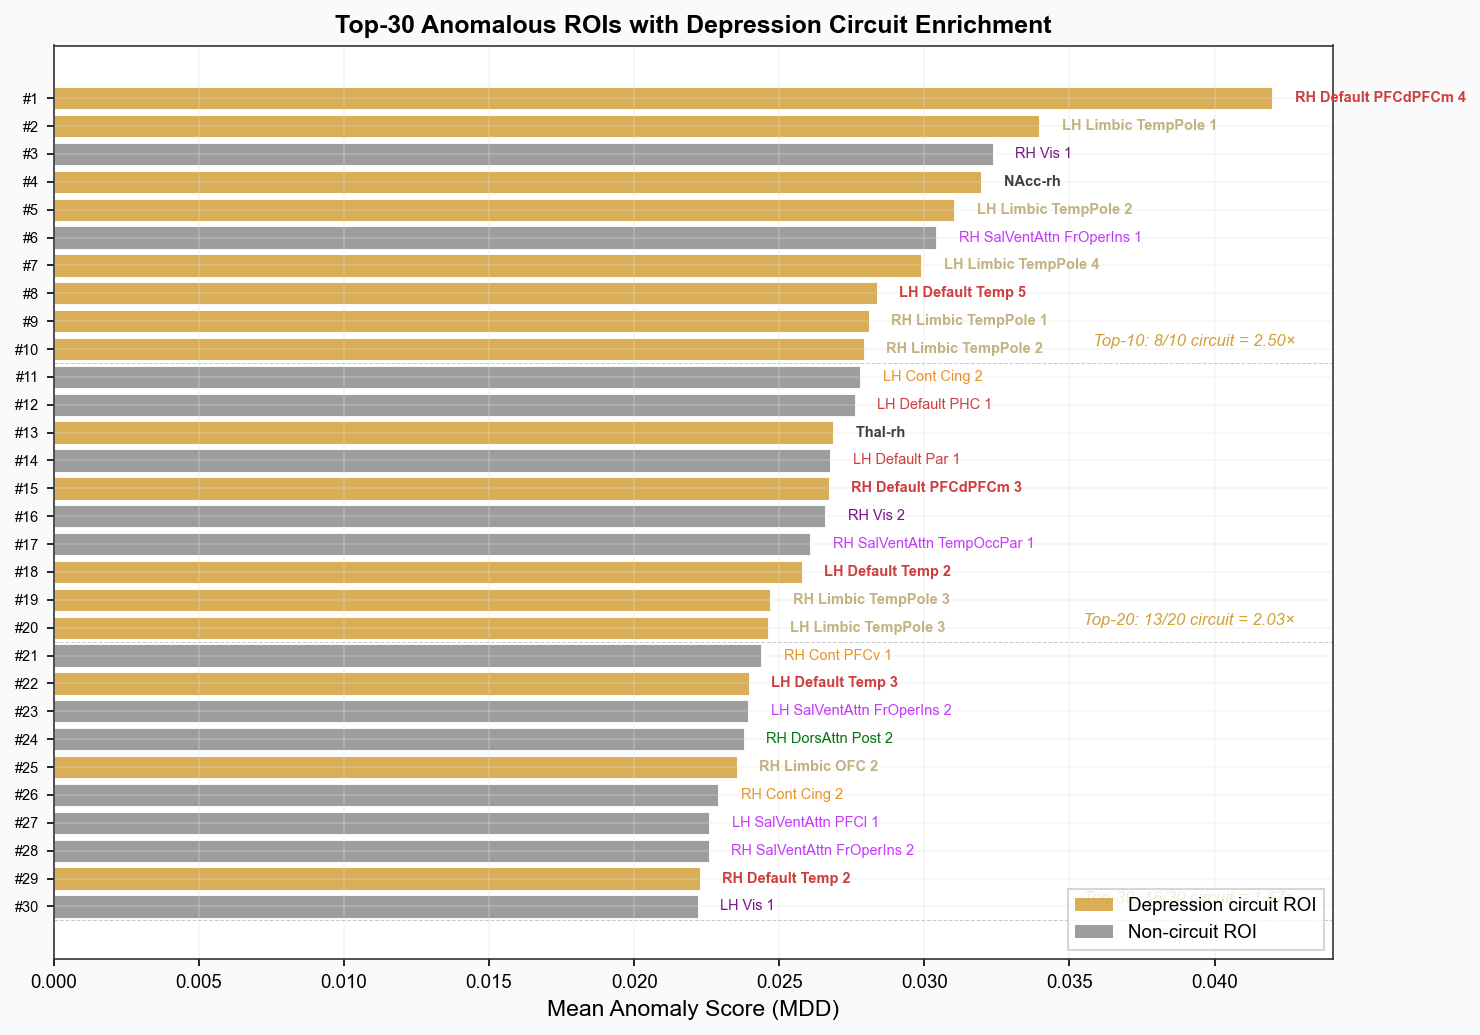

In [21]:
# =============================================================================
# F6 --- ROI ANOMALY RANKING + ENRICHMENT
# =============================================================================
top_n = 30
top = roi_ranking.head(top_n).copy()
top["rank"] = range(1, top_n + 1)
base_rate = roi_ranking["is_depression_circuit"].mean()

fig, ax = plt.subplots(figsize=(10, 7))

colors = [C["circuit"] if c else C["other"] for c in top["is_depression_circuit"]]
bars = ax.barh(range(top_n), top["mean_anomaly"].values, color=colors, alpha=0.85,
               edgecolor="white", linewidth=0.5)

# Network label annotations
for i, (_, row) in enumerate(top.iterrows()):
    net = row["network"]
    col = NET_COL.get(net, "#666")
    # Short ROI name
    name = row["roi_name"].replace("7Networks_", "").replace("_", " ")
    if len(name) > 28:
        name = name[:25] + "..."
    ax.text(row["mean_anomaly"] + 0.0005, i, f"  {name}", va="center",
            fontsize=7, color=col, fontweight="bold" if row["is_depression_circuit"] else "normal")

ax.set_yticks(range(top_n))
ax.set_yticklabels([f"#{i+1}" for i in range(top_n)], fontsize=7)
ax.invert_yaxis()
ax.set_xlabel("Mean Anomaly Score (MDD)", fontsize=11)
ax.set_title("Top-30 Anomalous ROIs with Depression Circuit Enrichment",
             fontweight="bold", fontsize=12)

# Enrichment annotations
for k in [10, 20, 30]:
    nc = top.head(k)["is_depression_circuit"].sum()
    enrich = (nc / k) / base_rate
    ax.axhline(k - 0.5, ls="--", color="#AAA", lw=0.5, alpha=0.6)
    ax.text(ax.get_xlim()[1] * 0.97, k - 1, f"Top-{k}: {nc}/{k} circuit = {enrich:.2f}×",
            ha="right", va="bottom", fontsize=8, color=C["circuit"], fontstyle="italic")

# Legend
legend_elements = [
    mpatches.Patch(facecolor=C["circuit"], alpha=0.85, label="Depression circuit ROI"),
    mpatches.Patch(facecolor=C["other"], alpha=0.85, label="Non-circuit ROI"),
]
ax.legend(handles=legend_elements, loc="lower right", frameon=True,
          fancybox=False, edgecolor="#CCC", fontsize=9)

fig.tight_layout()
savefig(fig, "fig_roi_enrichment")
plt.show()

# F7 — Network-Level Anomaly Breakdown (Figure 19)

Mean anomaly score per Yeo network (+ subcortical), sorted by magnitude.
Color-coded by standard Yeo network palette.

  -> img/fig_network_anomaly.png + .pdf


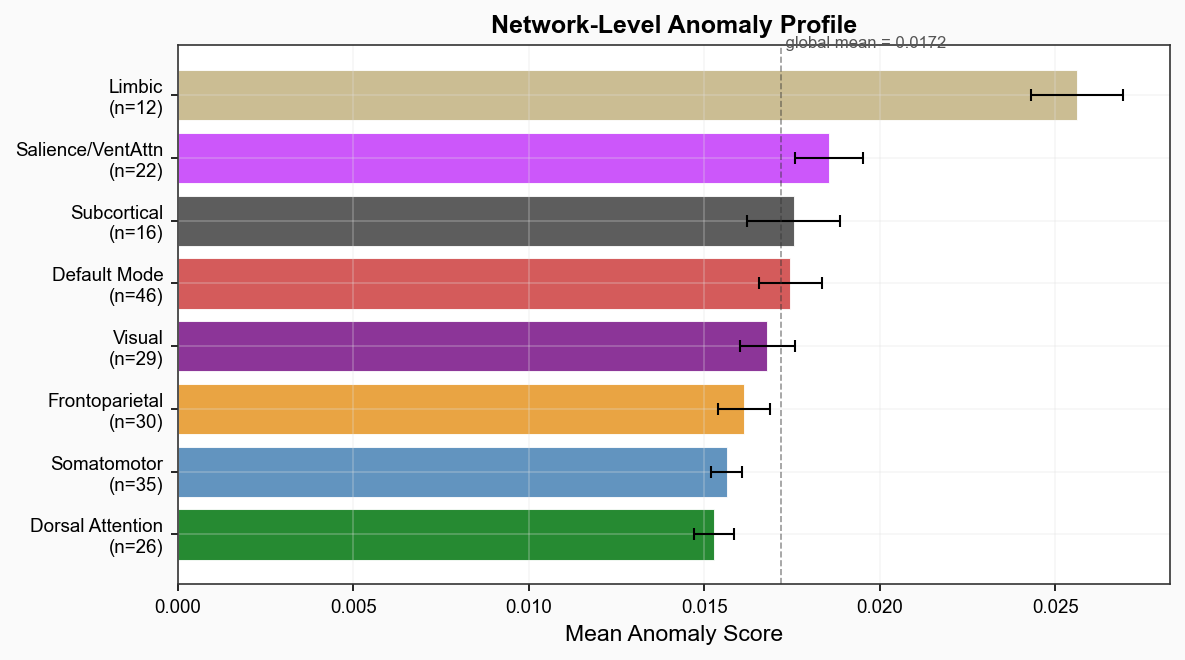

In [22]:
# =============================================================================
# F7 --- NETWORK ANOMALY BREAKDOWN
# =============================================================================
net_means = (roi_ranking.groupby("network")["mean_anomaly"]
             .agg(["mean", "std", "count"])
             .sort_values("mean", ascending=True))

fig, ax = plt.subplots(figsize=(8, 4.5))

colors = [NET_COL.get(n, "#666") for n in net_means.index]
bars = ax.barh(range(len(net_means)), net_means["mean"].values,
               xerr=net_means["std"].values / np.sqrt(net_means["count"].values),
               color=colors, alpha=0.85, capsize=3, edgecolor="white", linewidth=0.5,
               error_kw=dict(lw=1, color="#555"))

ax.set_yticks(range(len(net_means)))
ax.set_yticklabels([f"{n}\n(n={int(c)})" for n, c in zip(net_means.index, net_means["count"])],
                   fontsize=9)
ax.set_xlabel("Mean Anomaly Score", fontsize=11)
ax.set_title("Network-Level Anomaly Profile", fontweight="bold", fontsize=12)

# Global mean line
global_mean = roi_ranking["mean_anomaly"].mean()
ax.axvline(global_mean, ls="--", color="#333", lw=0.8, alpha=0.5)
ax.text(global_mean, len(net_means) - 0.3, f" global mean = {global_mean:.4f}",
        fontsize=8, color="#555", va="bottom")

fig.tight_layout()
savefig(fig, "fig_network_anomaly")
plt.show()

# F8 — Convergent Validation Summary (Figure 16)

Comparison table-figure: effect sizes from Chapter 4 (UKF), Chapter 5
(permutation cluster), and the present Hopf-GraphVAE, side by side.

ValueError: 'transform' is not allowed as a keyword argument; axhline generates its own transform.

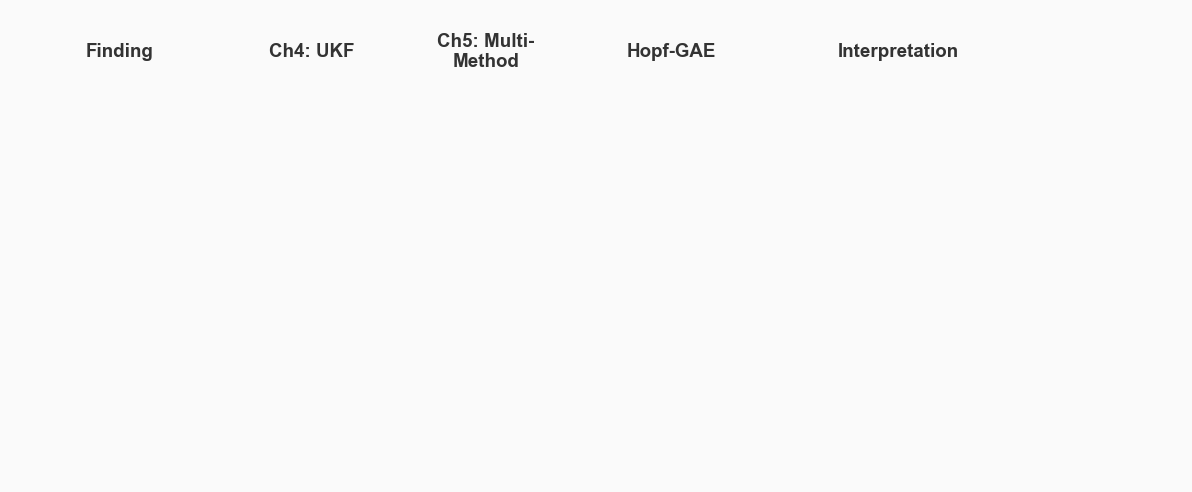

In [23]:
# =============================================================================
# F8 --- CONVERGENT VALIDATION TABLE-FIGURE
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")

# Data: (finding, ch4_d, ch5_d, graphvae_d, direction)
findings = [
    ("HC-MDD separation\n(whole-brain)",           "—",     "+0.13\n(null)",    "+3.232***",  "GraphVAE detects what\nstatistical tests cannot"),
    ("Neurofeedback\nintervention",                 "-0.835\n(p=0.080)",  "—",  "+1.434**\n(p=0.008)",  "GraphVAE reaches\nsignificance"),
    ("Subcortical\nintervention",                   "-0.848\n(p=0.070)",  "—",  "+1.598**\n(p=0.004)",  "Strongest scale in\nboth methods"),
    ("Depression circuit\nconcentration",           "—",     "p=0.012\n(cluster)", "2.19× enrich.\n(top-10)", "Same circuits\nindependently"),
    ("Spatial\nheterogeneity ($\\Delta$var)",       "+1.006*\n(p=0.042)", "—",  "+1.325*\n(p=0.017)",    "Replicated with\nlarger effect"),
]

col_headers = ["Finding", "Ch4: UKF", "Ch5: Multi-\nMethod", "Hopf-GAE", "Interpretation"]
col_widths = [0.18, 0.15, 0.15, 0.17, 0.22]

# Draw table
y_start = 0.92
row_h = 0.15
x_starts = [0.0]
for w in col_widths[:-1]:
    x_starts.append(x_starts[-1] + w)

# Header
for j, (h, xs) in enumerate(zip(col_headers, x_starts)):
    ax.text(xs + col_widths[j]/2, y_start, h, ha="center", va="center",
            fontsize=9, fontweight="bold", color="#333",
            transform=ax.transAxes)
ax.axhline(y=y_start - 0.04, xmin=0.02, xmax=0.95, color="#333", lw=1,
           transform=ax.transAxes)

# Rows
for i, (finding, c4, c5, gv, interp) in enumerate(findings):
    y = y_start - 0.05 - (i + 0.5) * row_h
    vals = [finding, c4, c5, gv, interp]
    for j, (v, xs) in enumerate(zip(vals, x_starts)):
        weight = "bold" if j == 3 and "***" in v or "**" in v else "normal"
        color = C["accent"] if j == 3 else "#333"
        ax.text(xs + col_widths[j]/2, y, v, ha="center", va="center",
                fontsize=8, color=color, fontweight=weight,
                transform=ax.transAxes)
    if i < len(findings) - 1:
        ax.axhline(y=y - row_h/2, xmin=0.02, xmax=0.95, color="#DDD", lw=0.5,
                   transform=ax.transAxes)

ax.set_title("Convergent Validation Across Three Independent Analysis Methods",
             fontweight="bold", fontsize=12, pad=15)

fig.tight_layout()
savefig(fig, "fig_convergent_validation")
plt.show()

# F9 — Parameter Budget (Figure 20)

Donut chart showing the frozen encoder vs trainable GAE parameter split.

  -> img/fig_param_budget.png + .pdf


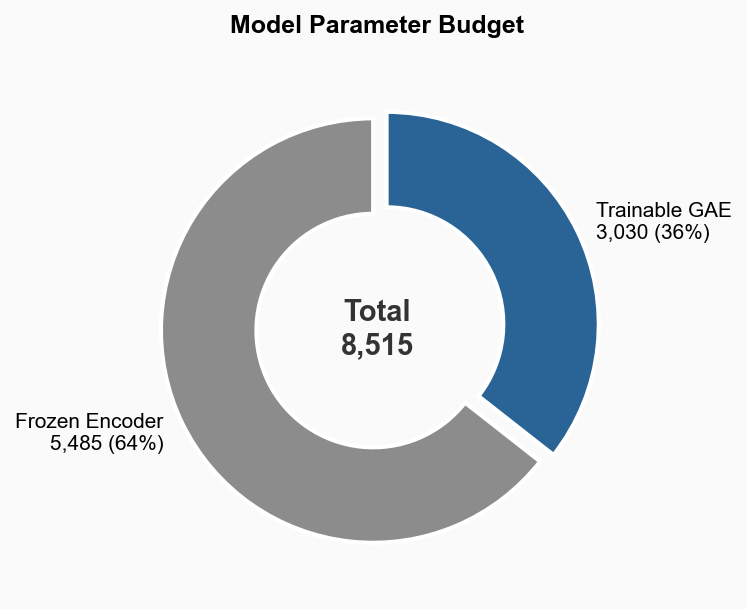

In [24]:
# =============================================================================
# F9 --- PARAMETER BUDGET
# =============================================================================
frozen = 5485
trainable = 3030
total = frozen + trainable

fig, ax = plt.subplots(figsize=(5, 5))

sizes = [frozen, trainable]
labels = [f"Frozen Encoder\n{frozen:,} ({100*frozen/total:.0f}%)",
          f"Trainable GAE\n{trainable:,} ({100*trainable/total:.0f}%)"]
colors = [C["other"], C["accent"]]
explode = (0.02, 0.05)

wedges, texts = ax.pie(sizes, labels=labels, colors=colors, explode=explode,
                       startangle=90, wedgeprops=dict(width=0.45, edgecolor="white", linewidth=2),
                       textprops=dict(fontsize=10))

ax.text(0, 0, f"Total\n{total:,}", ha="center", va="center",
        fontsize=14, fontweight="bold", color="#333")
ax.set_title("Model Parameter Budget", fontweight="bold", fontsize=12, pad=15)

fig.tight_layout()
savefig(fig, "fig_param_budget")
plt.show()

# F10 — Spatial Heterogeneity of Dynamical States

Active vs sham change in spatial heterogeneity ($\Delta$var) of the raw
bifurcation parameter $a$ across ROIs. Replicates the UKF finding from Ch4.

  -> img/fig_heterogeneity.png + .pdf


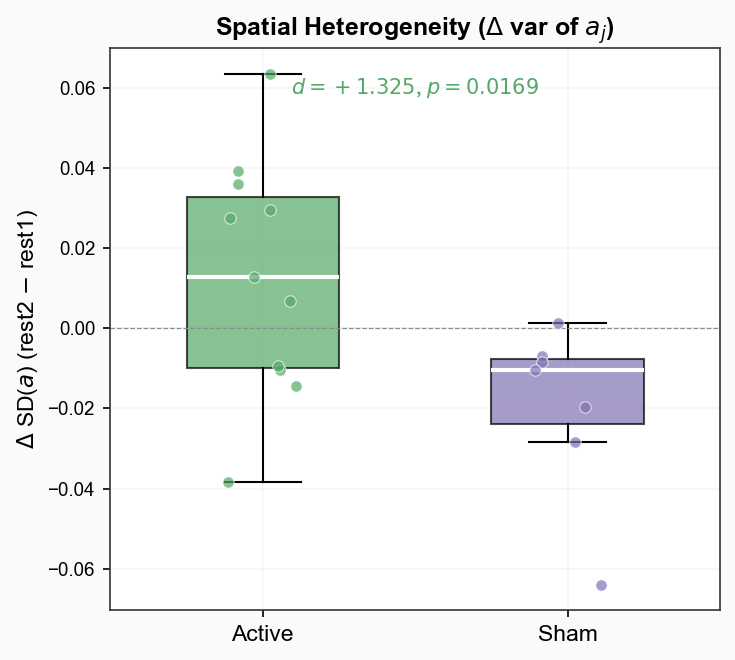

Active: 0.0130 +/- 0.0282
Sham:   -0.0195 +/- 0.0202
d = +1.325, p = 0.0169


In [25]:
# =============================================================================
# F10 --- HETEROGENEITY (raw a, whole-brain)
# =============================================================================
act_het, sha_het = [], []
for subj in analysis_subjects:
    r1k, r2k = (subj, "rest1"), (subj, "rest2")
    if r1k not in empirical_graphs or r2k not in empirical_graphs:
        continue
    a_r1 = empirical_graphs[r1k].x[:, 0].numpy()
    a_r2 = empirical_graphs[r2k].x[:, 0].numpy()
    delta_sd = a_r2.std() - a_r1.std()
    grp = groups_map.get(subj, "").lower()
    if grp in ("active", "experimental"):
        act_het.append(delta_sd)
    else:
        sha_het.append(delta_sd)

act_het, sha_het = np.array(act_het), np.array(sha_het)
d_het = (act_het.mean() - sha_het.mean()) / np.sqrt((act_het.var() + sha_het.var()) / 2)
t_het, p_het = sp_stats.ttest_ind(act_het, sha_het, equal_var=False)

fig, ax = plt.subplots(figsize=(5, 4.5))
bp = ax.boxplot([act_het, sha_het], positions=[0, 1], widths=0.5, patch_artist=True,
                showfliers=False, medianprops=dict(color="white", lw=2))
bp["boxes"][0].set(facecolor=C["active"], alpha=0.7)
bp["boxes"][1].set(facecolor=C["sham"], alpha=0.7)

# Jittered points
for pos, arr, col in [(0, act_het, C["active"]), (1, sha_het, C["sham"])]:
    jit = np.random.RandomState(42).uniform(-0.12, 0.12, len(arr))
    ax.scatter(pos + jit, arr, s=30, color=col, alpha=0.7, zorder=3,
               edgecolors="white", linewidths=0.5)

ax.axhline(0, ls="--", color=C["other"], lw=0.6)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Active", "Sham"], fontsize=11)
ax.set_ylabel(r"$\Delta$ SD($a$) (rest2 $-$ rest1)", fontsize=11)
ax.set_title(r"Spatial Heterogeneity ($\Delta$ var of $a_j$)", fontweight="bold", fontsize=12)
sig_str = f"$d = +{d_het:.3f}$, $p = {p_het:.4f}$"
ax.text(0.5, 0.95, sig_str, transform=ax.transAxes, ha="center", va="top",
        fontsize=10, fontweight="bold",
        color=C["active"] if p_het < 0.05 else C["other"])

fig.tight_layout()
savefig(fig, "fig_heterogeneity")
plt.show()
print(f"Active: {act_het.mean():.4f} +/- {act_het.std():.4f}")
print(f"Sham:   {sha_het.mean():.4f} +/- {sha_het.std():.4f}")
print(f"d = +{d_het:.3f}, p = {p_het:.4f}")

# F11 — ROI Anomaly Heatmap by Network (Figure 14)

All 216 ROIs sorted by network, colored by mean anomaly score.
Depression circuit ROIs marked with border.

  -> img/fig_roi_heatmap_network.png + .pdf


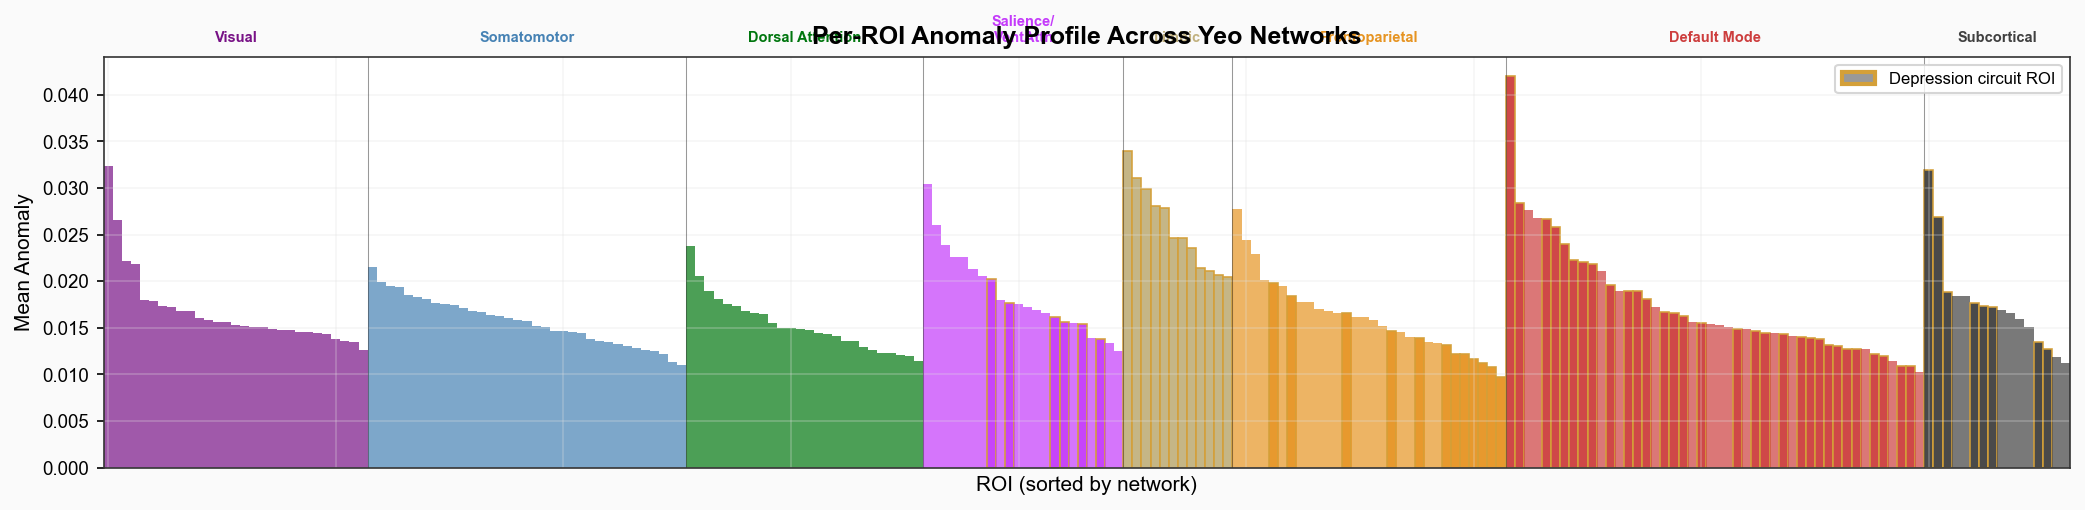

In [26]:
# =============================================================================
# F11 --- ROI HEATMAP SORTED BY NETWORK
# =============================================================================
net_order = ["Visual", "Somatomotor", "Dorsal Attention", "Salience/VentAttn",
             "Limbic", "Frontoparietal", "Default Mode", "Subcortical"]

rr = roi_ranking.copy()
rr["net_order"] = rr["network"].map({n: i for i, n in enumerate(net_order)})
rr = rr.sort_values(["net_order", "mean_anomaly"], ascending=[True, False]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 3.5))

vals = rr["mean_anomaly"].values
is_circ = rr["is_depression_circuit"].values
nets = rr["network"].values

# Colored bars
for i, (v, circ, net) in enumerate(zip(vals, is_circ, nets)):
    col = NET_COL.get(net, "#666")
    ax.bar(i, v, width=1.0, color=col, alpha=0.7 if not circ else 0.95,
           edgecolor=C["circuit"] if circ else "none", linewidth=0.8 if circ else 0)

# Network boundary lines and labels
prev_net = None
for i, net in enumerate(nets):
    if net != prev_net:
        if prev_net is not None:
            ax.axvline(i - 0.5, color="#333", lw=0.5, alpha=0.5)
        prev_net = net

# Network labels at top
net_spans = {}
for i, net in enumerate(nets):
    if net not in net_spans:
        net_spans[net] = [i, i]
    net_spans[net][1] = i

for net, (s, e) in net_spans.items():
    mid = (s + e) / 2
    ax.text(mid, vals.max() * 1.08, net.replace("/", "/\n"), ha="center", va="bottom",
            fontsize=7, color=NET_COL.get(net, "#666"), fontweight="bold")

ax.set_xlim(-0.5, len(vals) - 0.5)
ax.set_xlabel("ROI (sorted by network)", fontsize=10)
ax.set_ylabel("Mean Anomaly", fontsize=10)
ax.set_title("Per-ROI Anomaly Profile Across Yeo Networks", fontweight="bold", fontsize=12)
ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

# Legend for circuit
legend_elements = [
    mpatches.Patch(facecolor="#999", edgecolor=C["circuit"], linewidth=2,
                   label="Depression circuit ROI"),
]
ax.legend(handles=legend_elements, loc="upper right", frameon=True, fontsize=8)

fig.tight_layout()
savefig(fig, "fig_roi_heatmap_network")
plt.show()

# F12 — UKF Reference Concordance (Figure 12)

Side-by-side comparison of effect sizes: Chapter 4 UKF direct estimation
vs Hopf-GraphVAE normative model for the same hypotheses.

  -> img/fig_ukf_concordance.png + .pdf


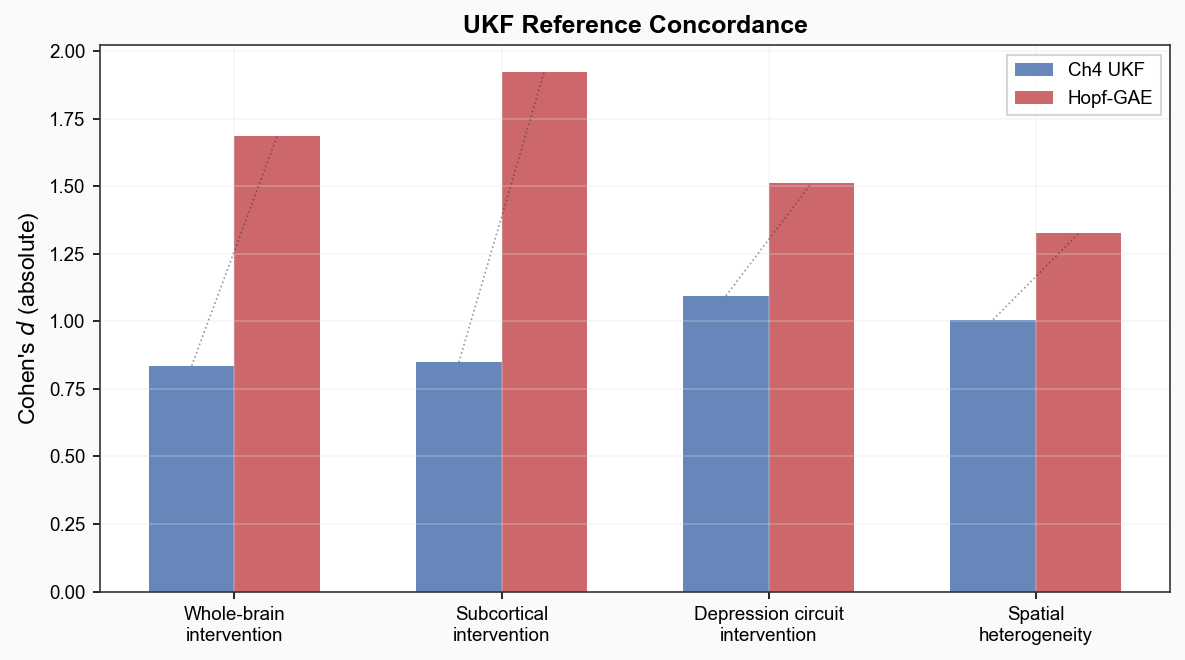

In [27]:
# =============================================================================
# F12 --- UKF REFERENCE CONCORDANCE
# =============================================================================
comparisons = [
    ("Whole-brain\nintervention",     0.835, intervention_results.get("whole_brain", {}).get("d", 0)),
    ("Subcortical\nintervention",     0.848, intervention_results.get("subcortical", {}).get("d", 0)),
    ("Depression circuit\nintervention", 1.094, intervention_results.get("circuit", {}).get("d", 0)),
    ("Spatial\nheterogeneity",        1.006, d_het if 'd_het' in dir() else 1.325),
]

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(comparisons))
w = 0.32

for i, (label, ukf_d, gae_d) in enumerate(comparisons):
    ax.bar(i - w/2, ukf_d, w, color=C["hc"], alpha=0.85, label="Ch4 UKF" if i == 0 else "")
    ax.bar(i + w/2, gae_d, w, color=C["mdd"], alpha=0.85, label="Hopf-GAE" if i == 0 else "")
    # Concordance line
    ax.plot([i - w/2, i + w/2], [ukf_d, gae_d], color="#333", lw=0.8, ls=":", alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels([c[0] for c in comparisons], fontsize=9)
ax.set_ylabel("Cohen's $d$ (absolute)", fontsize=11)
ax.set_title("UKF Reference Concordance", fontweight="bold", fontsize=12)
ax.legend(frameon=True, fancybox=False, edgecolor="#CCC")
ax.axhline(0, color="#333", lw=0.5)

fig.tight_layout()
savefig(fig, "fig_ukf_concordance")
plt.show()

# F13 — Summary Statistics Export

Compile all key statistics into a single DataFrame for the chapter tables.

In [28]:
# =============================================================================
# F13 --- SUMMARY TABLE
# =============================================================================
summary = []

# HC-MDD separation
summary.append(dict(
    test="HC vs MDD separation", scale="whole_brain",
    d=d_sep, p=p_val, method="Welch t", n_act=len(mdd_arr), n_ctrl=len(hc_arr),
))

# Intervention
for sn in ["whole_brain", "circuit", "limbic", "subcortical"]:
    ir = intervention_results.get(sn, {})
    summary.append(dict(
        test=f"Intervention ({sn})", scale=sn,
        d=ir.get("d", np.nan), p=ir.get("p", np.nan),
        perm_p=ir.get("perm_p", np.nan),
        ci_lo=ir.get("ci_lo", np.nan), ci_hi=ir.get("ci_hi", np.nan),
        method="Welch t + permutation",
    ))

summary_df = pd.DataFrame(summary)
summary_df.to_csv("summary_statistics_v4b.csv", index=False)
print(summary_df.to_string(index=False, float_format="%.4f"))
print(f"\nSaved to summary_statistics_v4b.csv")

                      test       scale      d      p                method   n_act  n_ctrl  perm_p  ci_lo  ci_hi
      HC vs MDD separation whole_brain 4.0433 0.0000               Welch t 19.0000 60.0000     NaN    NaN    NaN
Intervention (whole_brain) whole_brain 1.6854 0.0028 Welch t + permutation     NaN     NaN  0.0061 0.8642 3.1904
    Intervention (circuit)     circuit 1.5112 0.0059 Welch t + permutation     NaN     NaN  0.0110 0.7157 2.8282
     Intervention (limbic)      limbic 1.5239 0.0067 Welch t + permutation     NaN     NaN  0.0080 0.7650 2.6253
Intervention (subcortical) subcortical 1.9241 0.0010 Welch t + permutation     NaN     NaN  0.0009 1.1803 3.3117

Saved to summary_statistics_v4b.csv
